# Youth Opportunity Index 2.0: Z-Score Methodology and Sensitivity Analysis

This notebook implements the updated Youth Opportunity Index (YOI) methodology for San Diego County. The goal is to improve the current index by moving from percentile-based indicator scoring to a z-score-based method that compares each Census tract to the county average.

## Purpose

The YOI measures neighborhood conditions that shape youth wellbeing, development, and access to opportunity. It is a multidimensional index, meaning it does not rely on only one outcome such as income, education, or health. Instead, it combines seven domains of youth opportunity:

1. Economic Opportunity
2. Education Opportunity
3. Health Opportunity
4. Housing Stability
5. Safety and Environment
6. Mobility and Connectivity
7. Youth Supports

## Main Methodology Changes

This notebook makes four main improvements to the index calculation:

* **Uses z-scores instead of percentile-ranked indicators**
  Each indicator is standardized relative to the San Diego County average. This keeps information about how far each tract is above or below the county average.

* **Reverses lower-is-better indicators**
  Indicators such as poverty, unemployment, crime, rent burden, and uninsured rate are reversed so that higher values always represent greater youth opportunity.

* **Calculates domain scores before the overall score**
  Indicators are first combined within their assigned domain. The seven domain scores are then combined into the overall YOI score.

* **Uses equal domain weights as the default baseline**
  Each domain contributes equally to the final YOI score. This prevents the index from being dominated by domains with more indicators or by indicators closely tied to income.

## Final Score Interpretation

The final YOI score is converted to a county-average-centered 0–100 scale.

* **50** means approximately county average
* **Above 50** means higher measured youth opportunity than the county average
* **Below 50** means lower measured youth opportunity than the county average

This is not a percentile rank. The score does not force equal numbers of Census tracts into each category.

## Validation and Sensitivity Analysis

The notebook also tests whether the index is robust by:

* comparing the updated YOI to outside benchmarks such as the Child Opportunity Index, SVI, Opportunity Atlas, and health-related indicators when available;
* recalculating the YOI using alternative weighting methods;
* identifying tracts whose scores remain stable or change substantially under different weighting assumptions.

The purpose of these checks is to determine whether the index results are stable, interpretable, and defensible.


## Cell 1 — Imports
- Loads Python libraries such as pandas, numpy, matplotlib, and file path tools.

In [30]:
from pathlib import Path
import re
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 250)
pd.set_option("display.width", 250)

## Cell 2 — Project paths
- Finds the repository root.
- Defines input and output folders.
- Sets paths for YOI components, metadata, boundaries, overlays, and saved outputs.

In [31]:
def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for p in [start] + list(start.parents):
        if (p / "data").exists():
            return p
    raise FileNotFoundError("Could not find repo root containing /data.")

REPO_ROOT = find_repo_root()
DATA_DIR = REPO_ROOT / "data"

RAW_DOMAINS = DATA_DIR / "rawdomains"
YOI_DIR = DATA_DIR / "processed" / "yoi"
BOUNDARY_DIR = DATA_DIR / "processed" / "boundaries"
OVERLAY_DIR = DATA_DIR / "processed" / "overlays"

INPUT_COMPONENTS = YOI_DIR / "yoi_components.csv"
INPUT_META = YOI_DIR / "yoi_indicator_meta.csv"

OUTPUT_COMPONENTS = YOI_DIR / "yoi_components_zscore_corrected.csv"
OUTPUT_META = YOI_DIR / "yoi_zscore_indicator_meta_corrected.csv"
OUTPUT_SENSITIVITY = YOI_DIR / "yoi_sensitivity_analysis_corrected.csv"
OUTPUT_VALIDATION = YOI_DIR / "yoi_validation_summary_corrected.csv"

print("Repo root:", REPO_ROOT)
print("Input YOI:", INPUT_COMPONENTS)
print("Input metadata:", INPUT_META)

Repo root: /Users/laurenvo/Documents/github/youth_opportunity_index
Input YOI: /Users/laurenvo/Documents/github/youth_opportunity_index/data/processed/yoi/yoi_components.csv
Input metadata: /Users/laurenvo/Documents/github/youth_opportunity_index/data/processed/yoi/yoi_indicator_meta.csv


## Cell 3 — Load current YOI components and metadata
- Loads the existing YOI component file.
- Loads the indicator metadata file.
- Standardizes Census tract GEOIDs.
- Confirms which indicators are available.

In [32]:
if not INPUT_COMPONENTS.exists():
    raise FileNotFoundError(f"Missing {INPUT_COMPONENTS}. Run your current YOI build script first.")

if not INPUT_META.exists():
    raise FileNotFoundError(f"Missing {INPUT_META}. Run your current YOI build script first.")

yoi_old = pd.read_csv(INPUT_COMPONENTS, dtype={"tract_geoid": str})
meta = pd.read_csv(INPUT_META)

yoi_old["tract_geoid"] = (
    yoi_old["tract_geoid"]
    .astype(str)
    .str.replace(r"\D", "", regex=True)
    .str.zfill(11)
    .str[-11:]
)

required_meta_cols = {"indicator", "domain", "higher_is_better"}
missing_meta_cols = required_meta_cols - set(meta.columns)

if missing_meta_cols:
    raise ValueError(f"Metadata missing required columns: {missing_meta_cols}")

meta = meta[meta["indicator"].isin(yoi_old.columns)].copy()

print("YOI rows:", len(yoi_old))
print("Indicators in metadata and CSV:", len(meta))

display(meta)
display(yoi_old.head())

YOI rows: 737
Indicators in metadata and CSV: 25


,indicator,domain,higher_is_better,source,notes
0,poverty_rate,economic,False,ACS S1701,column=S1701_C02_001E
1,median_hh_income,economic,True,ACS B19013,column=B19013_001E
2,unemployment_rate,economic,False,ACS S2301,column=S2301_C04_001E
3,snap_or_assist_rate,economic,False,ACS S2201,column=S2201_C02_013E
4,hs_plus,education,True,ACS S1501,hs_col=S1501_C02_015E
5,ba_plus,education,True,ACS S1501,ba_col=S1501_C03_016E
6,school_enrollment,education,True,ACS S1401,column=S1401_C04_001E
7,youth_disconnection_proxy,education,False,ACS B14005,share of population age 16-19 who are not enro...
8,uninsured_rate,health,False,ACS S2701,column=S2701_C02_001E
9,disability_rate,health,False,ACS S1810,column=S1810_C02_001E


,tract_geoid,economic_score,economic_coverage,education_score,education_coverage,health_score,health_coverage,housing_score,housing_coverage,safety_env_score,safety_env_coverage,mobility_connectivity_score,mobility_connectivity_coverage,youth_supports_score,youth_supports_coverage,yoi_domain_coverage,yoi_raw_0_1,yoi_0_100,total_population,poverty_rate,median_hh_income,unemployment_rate,snap_or_assist_rate,hs_plus,ba_plus,school_enrollment,youth_disconnection_proxy,uninsured_rate,disability_rate,frequent_mental_distress,poor_physical_health,rent_burden_proxy,overcrowding_proxy,moved_past_year_proxy,homeownership_rate,single_parent_proxy,vacancy_rate,crime_rate_per_1k,env_burden,no_vehicle_rate,commute_time_proxy,internet_sub_rate_proxy,service_count,services_per_10k,norm_poverty_rate,norm_median_hh_income,norm_unemployment_rate,norm_snap_or_assist_rate,norm_hs_plus,norm_ba_plus,norm_school_enrollment,norm_youth_disconnection_proxy,norm_uninsured_rate,norm_disability_rate,norm_frequent_mental_distress,norm_poor_physical_health,norm_rent_burden_proxy,norm_overcrowding_proxy,norm_moved_past_year_proxy,norm_homeownership_rate,norm_single_parent_proxy,norm_vacancy_rate,norm_crime_rate_per_1k,norm_env_burden,norm_no_vehicle_rate,norm_commute_time_proxy,norm_internet_sub_rate_proxy,norm_service_count,norm_services_per_10k,youth_service_count,mh_service_count,youth_services_per_10k,mh_services_per_10k,lack_transport
0,06073017039,0.573915,1.0,0.749792,1.0,0.598263,1.0,0.527995,1.0,0.675539,1.0,0.693304,1.0,0.937118,1.0,1.0,0.679418,67.941798,6711,352,135750.0,4.7,4.8,61.9,642,88.8,0.000000,6452,291,14.1,9.9,50.383632,3.456134,17.109635,68.552981,21.151586,2.155333,9.089554,30.528936,0.645651,27.136150,95.138625,27.0,40.232454,0.485753,0.728155,0.578338,0.503415,0.760218,0.884668,0.658719,0.695562,0.052917,0.750339,0.804762,0.785034,0.662107,0.588798,0.231293,0.629781,0.567493,0.733607,0.842177,0.558879,0.893443,0.752044,0.434426,0.968114,0.906122,4.0,0.0,5.960364,0.0,5.7
1,06073017040,0.586179,1.0,0.505535,1.0,0.577510,1.0,0.672448,1.0,0.721669,1.0,0.712890,1.0,0.486414,1.0,1.0,0.608949,60.894925,4386,329,166042.0,6.1,4.0,59.2,105,85.0,0.000000,4304,503,14.0,10.5,70.642202,1.072386,7.144547,91.487936,12.623274,0.000000,20.519836,22.850031,0.000000,35.414013,97.587131,5.0,11.399909,0.510855,0.877947,0.385559,0.570355,0.727520,0.097015,0.502044,0.695562,0.392130,0.418589,0.816327,0.682993,0.173735,0.823770,0.748299,0.943989,0.756198,0.940574,0.517007,0.672897,0.967896,0.497275,0.673497,0.485753,0.487075,3.0,0.0,6.839945,0.0,5.5
2,06073017043,0.770469,1.0,0.581141,1.0,0.628792,1.0,0.546416,1.0,0.777464,1.0,0.672294,1.0,0.884461,1.0,1.0,0.694434,69.443377,5590,248,175450.0,3.8,1.4,69.4,413,87.5,9.090909,5294,451,13.2,8.4,62.644628,6.638616,6.171735,71.715755,7.099698,0.000000,15.742397,26.172993,4.160823,24.148488,97.989715,17.0,30.411449,0.625509,0.907074,0.709128,0.840164,0.865804,0.668928,0.617847,0.171983,0.185889,0.489145,0.887755,0.952381,0.347469,0.366120,0.813605,0.658470,0.895317,0.940574,0.657143,0.616822,0.461749,0.821526,0.733607,0.921303,0.847619,1.0,0.0,1.788909,0.0,4.9
3,06073003103,0.500664,1.0,0.478576,1.0,0.184932,1.0,0.649999,1.0,0.702295,1.0,0.178875,1.0,0.731557,1.0,1.0,0.489557,48.955667,6442,436,118317.0,4.6,5.8,16.0,689,93.5,20.921986,6044,932,17.6,13.9,42.372881,7.798960,9.892541,92.836511,16.615385,0.000000,20.645762,20.584941,6.816869,53.035845,91.334489,11.0,17.075442,0.388738,0.597781,0.594005,0.422131,0.095368,0.910448,0.844687,0.063800,0.092266,0.056988,0.340816,0.249660,0.792066,0.312842,0.531973,0.963115,0.651515,0.940574,0.514286,0.702804,0.267760,0.095368,0.173497,0.805970,0.657143,1.0,0.0,1.552313,0.0,12.1
4,06073003105,0.393974,1.0,0.515278,1.0,0.369414,1.0,0.500808,1.0,0.763272,1.0,0.354246,1.0,0.908941,1.0,1.0,0.543705,54.370473,4870,413,112842.0,5.6,11.5,26.0,501,90.4,4.375000,4574,359,17.7,14.5,83.582090,7.615385,4.476386,79.153846,14.181818,0.306748,12.114990,20.435594,5.076923,62.782152,97.307692,

## Cell 4 — Domains and equal default domain weights
- Defines the seven YOI domains.
- Assigns each domain equal weight.
- Confirms each domain contributes about 14.3% to the default overall score.

In [33]:
DOMAINS = [
    "economic",
    "education",
    "health",
    "housing",
    "safety_env",
    "mobility_connectivity",
    "youth_supports",
]

DOMAIN_LABELS = {
    "economic": "Economic Opportunity",
    "education": "Education Opportunity",
    "health": "Health Opportunity",
    "housing": "Housing Stability",
    "safety_env": "Safety and Environment",
    "mobility_connectivity": "Mobility and Connectivity",
    "youth_supports": "Youth Supports",
}

DEFAULT_DOMAIN_WEIGHTS = {d: 1 / len(DOMAINS) for d in DOMAINS}

pd.DataFrame({
    "domain": DOMAINS,
    "label": [DOMAIN_LABELS[d] for d in DOMAINS],
    "default_weight": [DEFAULT_DOMAIN_WEIGHTS[d] for d in DOMAINS],
    "default_weight_percent": [DEFAULT_DOMAIN_WEIGHTS[d] * 100 for d in DOMAINS],
})

,domain,label,default_weight,default_weight_percent
0,economic,Economic Opportunity,0.142857,14.285714
1,education,Education Opportunity,0.142857,14.285714
2,health,Health Opportunity,0.142857,14.285714
3,housing,Housing Stability,0.142857,14.285714
4,safety_env,Safety and Environment,0.142857,14.285714
5,mobility_connectivity,Mobility and Connectivity,0.142857,14.285714
6,youth_supports,Youth Supports,0.142857,14.285714


## Cell 5 — Helper functions
- Defines reusable functions for:
    - cleaning GEOIDs,
    - loading Census tables,
    - converting strings to numbers,
    - calculating percentages,
    - validating percent columns,
    - replacing indicators safely.

In [34]:
def digits_only(x):
    return re.sub(r"\D", "", str(x))

def geoid11_from_any(x):
    if pd.isna(x):
        return None
    d = digits_only(x)
    if len(d) >= 11:
        return d[-11:]
    return None

def sd_only(df, geoid_col="tract_geoid"):
    df = df.dropna(subset=[geoid_col]).copy()
    df[geoid_col] = df[geoid_col].astype(str).str.zfill(11).str[-11:]
    return df[df[geoid_col].str.startswith("06073")].copy()

def safe_num(x):
    if isinstance(x, pd.DataFrame):
        return x.apply(pd.to_numeric, errors="coerce")
    return pd.to_numeric(x, errors="coerce")

def ratio_percent(numerator, denominator):
    numerator = safe_num(numerator)
    denominator = safe_num(denominator)
    return np.where(denominator > 0, numerator / denominator * 100.0, np.nan)

def find_latest_table_folder(domain_dir, prefix):
    if not domain_dir.exists():
        return None
    candidates = [p for p in domain_dir.iterdir() if p.is_dir() and p.name.startswith(prefix + "_")]
    if not candidates:
        return None
    return sorted(candidates, key=lambda p: p.name)[-1]

def load_census_table(domain, prefix):
    # Loads latest Census table and returns (San Diego tract dataframe, labels dictionary).
    domain_dir = RAW_DOMAINS / domain
    folder = find_latest_table_folder(domain_dir, prefix)

    if folder is None:
        return None, {}

    data_csv = next(folder.glob("*-Data.csv"), None)

    if data_csv is None:
        return None, {}

    raw = pd.read_csv(data_csv, low_memory=False)

    labels = {}
    if len(raw) > 0:
        first_row = raw.iloc[0].astype(str).to_dict()
        if any("Estimate" in v or "Percent" in v or "Margin of Error" in v for v in first_row.values()):
            labels = first_row

    df = raw.copy()

    geo_col = None
    for cand in ["tract_geoid", "GEOID", "GEO_ID", "geo_id", "LocationName", "locationname"]:
        if cand in df.columns:
            geo_col = cand
            break

    if geo_col is None:
        geo_col = df.columns[0]

    df["tract_geoid"] = df[geo_col].apply(geoid11_from_any)
    df = sd_only(df)

    return df, labels

def valid_percent_series(s, min_coverage=0.50):
    s = safe_num(s)
    if s.notna().mean() < min_coverage:
        return False
    vals = s.dropna()
    if len(vals) == 0:
        return False
    return vals.between(0, 100).all()

def choose_percent_column(df, labels, candidates, must_keywords=None, avoid_keywords=None, min_coverage=0.50):
    # Prefer explicit candidate columns. If no candidate works, search Census label text.
    must_keywords = [k.lower() for k in (must_keywords or [])]
    avoid_keywords = [k.lower() for k in (avoid_keywords or [])]

    for col in candidates:
        if col in df.columns and valid_percent_series(df[col], min_coverage=min_coverage):
            return col

    if labels:
        for col in df.columns:
            label = str(labels.get(col, "")).lower()
            if "percent" not in label:
                continue
            if must_keywords and not all(k in label for k in must_keywords):
                continue
            if avoid_keywords and any(k in label for k in avoid_keywords):
                continue
            if valid_percent_series(df[col], min_coverage=min_coverage):
                return col

    return None

def replace_indicator(df, replacement, col):
    if col not in replacement.columns:
        raise ValueError(f"Replacement dataframe does not contain {col}")

    out = df.drop(columns=[col], errors="ignore").copy()
    replacement = replacement[["tract_geoid", col]].copy()
    replacement["tract_geoid"] = replacement["tract_geoid"].astype(str).str.zfill(11).str[-11:]
    return out.merge(replacement, on="tract_geoid", how="left")

def to_bool(x):
    if isinstance(x, bool):
        return x
    if pd.isna(x):
        return False
    return str(x).strip().lower() in {"true", "1", "yes", "y"}

## Cell 6 — Fix risky raw indicators before z-scoring
- Corrects indicators that could accidentally be counts instead of rates.
- Fixes economic indicators like poverty, unemployment, and SNAP/public assistance.
- Fixes education indicators like high school attainment, bachelor’s attainment, and school enrollment.
- Fixes health indicators like uninsured rate and disability rate.
- Logs which indicators were fixed and from which source.

In [35]:
yoi_fixed = yoi_old.copy()
fix_log = []

def log_fix(indicator, status, source, notes=""):
    fix_log.append({
        "indicator": indicator,
        "status": status,
        "source": source,
        "notes": notes,
    })

# ----------------------------
# Economic indicators
# ----------------------------

# Poverty rate
s1701, s1701_labels = load_census_table("economic", "ACSST5Y2024.S1701")
if s1701 is not None:
    percent_col = choose_percent_column(
        s1701, s1701_labels,
        candidates=["S1701_C03_001E"],
        must_keywords=["below poverty", "percent"],
    )
    if percent_col:
        tmp = s1701[["tract_geoid"]].copy()
        tmp["poverty_rate"] = safe_num(s1701[percent_col])
        yoi_fixed = replace_indicator(yoi_fixed, tmp, "poverty_rate")
        log_fix("poverty_rate", "fixed", "ACS S1701", f"used percent column {percent_col}")
    elif all(c in s1701.columns for c in ["S1701_C02_001E", "S1701_C01_001E"]):
        tmp = s1701[["tract_geoid"]].copy()
        tmp["poverty_rate"] = ratio_percent(s1701["S1701_C02_001E"], s1701["S1701_C01_001E"])
        yoi_fixed = replace_indicator(yoi_fixed, tmp, "poverty_rate")
        log_fix("poverty_rate", "fixed", "ACS S1701", "calculated below poverty / total")
    else:
        log_fix("poverty_rate", "not fixed", "ACS S1701", "required columns missing")
else:
    log_fix("poverty_rate", "not fixed", "ACS S1701", "table not found")

# Unemployment rate
s2301, s2301_labels = load_census_table("economic", "ACSST5Y2024.S2301")
if s2301 is not None:
    percent_col = choose_percent_column(
        s2301, s2301_labels,
        candidates=["S2301_C04_001E"],
        must_keywords=["unemployment", "rate"],
    )
    if percent_col:
        tmp = s2301[["tract_geoid"]].copy()
        tmp["unemployment_rate"] = safe_num(s2301[percent_col])
        yoi_fixed = replace_indicator(yoi_fixed, tmp, "unemployment_rate")
        log_fix("unemployment_rate", "fixed", "ACS S2301", f"used unemployment rate column {percent_col}")
    else:
        log_fix("unemployment_rate", "not fixed", "ACS S2301", "could not find valid percent/rate column")
else:
    log_fix("unemployment_rate", "not fixed", "ACS S2301", "table not found")

# SNAP / public assistance rate
s2201, s2201_labels = load_census_table("economic", "ACSST5Y2024.S2201")
if s2201 is not None:
    percent_col = choose_percent_column(
        s2201, s2201_labels,
        candidates=["S2201_C04_001E", "S2201_C03_001E"],
        must_keywords=["receiving", "snap"],
    )

    if percent_col:
        tmp = s2201[["tract_geoid"]].copy()
        tmp["snap_or_assist_rate"] = safe_num(s2201[percent_col])
        yoi_fixed = replace_indicator(yoi_fixed, tmp, "snap_or_assist_rate")
        log_fix("snap_or_assist_rate", "fixed", "ACS S2201", f"used percent column {percent_col}")
    elif all(c in s2201.columns for c in ["S2201_C02_001E", "S2201_C01_001E"]):
        tmp = s2201[["tract_geoid"]].copy()
        tmp["snap_or_assist_rate"] = ratio_percent(s2201["S2201_C02_001E"], s2201["S2201_C01_001E"])
        if valid_percent_series(tmp["snap_or_assist_rate"]):
            yoi_fixed = replace_indicator(yoi_fixed, tmp, "snap_or_assist_rate")
            log_fix("snap_or_assist_rate", "fixed", "ACS S2201", "calculated receiving SNAP / total households")
        else:
            log_fix("snap_or_assist_rate", "not fixed", "ACS S2201", "calculated ratio failed percent validation")
    else:
        log_fix("snap_or_assist_rate", "not fixed", "ACS S2201", "required columns missing")
else:
    log_fix("snap_or_assist_rate", "not fixed", "ACS S2201", "table not found")

# ----------------------------
# Education indicators
# ----------------------------

# Clear old education values so stale/wrong values do not carry forward
for col in ["hs_plus", "ba_plus", "school_enrollment"]:
    if col in yoi_fixed.columns:
        yoi_fixed[col] = np.nan


# Education attainment from B15003, with S1501 fallback
b15003, b15003_labels = load_census_table("education", "ACSDT5Y2024.B15003")

if b15003 is not None:
    total_col = "B15003_001E"
    hs_plus_cols = [f"B15003_{i:03d}E" for i in range(17, 26)]
    ba_plus_cols = [f"B15003_{i:03d}E" for i in range(22, 26)]

    if all(c in b15003.columns for c in [total_col] + hs_plus_cols + ba_plus_cols):
        tmp = b15003[["tract_geoid"]].copy()

        total = safe_num(b15003[total_col])
        hs_plus = safe_num(b15003[hs_plus_cols]).sum(axis=1)
        ba_plus = safe_num(b15003[ba_plus_cols]).sum(axis=1)

        tmp["hs_plus"] = ratio_percent(hs_plus, total)
        tmp["ba_plus"] = ratio_percent(ba_plus, total)

        if valid_percent_series(tmp["hs_plus"]):
            yoi_fixed = replace_indicator(yoi_fixed, tmp[["tract_geoid", "hs_plus"]], "hs_plus")
            log_fix("hs_plus", "fixed", "ACS B15003", "calculated high school graduate or higher / population 25+")
        else:
            log_fix("hs_plus", "not fixed", "ACS B15003", "calculated values failed validation")

        if valid_percent_series(tmp["ba_plus"]):
            yoi_fixed = replace_indicator(yoi_fixed, tmp[["tract_geoid", "ba_plus"]], "ba_plus")
            log_fix("ba_plus", "fixed", "ACS B15003", "calculated bachelor's degree or higher / population 25+")
        else:
            log_fix("ba_plus", "not fixed", "ACS B15003", "calculated values failed validation")

    else:
        log_fix("hs_plus", "not fixed", "ACS B15003", "required columns missing")
        log_fix("ba_plus", "not fixed", "ACS B15003", "required columns missing")

else:
    s1501, s1501_labels = load_census_table("education", "ACSST5Y2024.S1501")

    if s1501 is not None:
        # Exact fallback based on ACS S1501:
        # S1501_C02_014E = Percent, population 25+, high school graduate or higher
        # S1501_C02_015E = Percent, population 25+, bachelor's degree or higher

        if "S1501_C02_014E" in s1501.columns:
            tmp = s1501[["tract_geoid"]].copy()
            tmp["hs_plus"] = safe_num(s1501["S1501_C02_014E"])

            if valid_percent_series(tmp["hs_plus"]):
                yoi_fixed = replace_indicator(yoi_fixed, tmp, "hs_plus")
                log_fix("hs_plus", "fixed", "ACS S1501", "used exact adult high school+ percent column S1501_C02_014E")
            else:
                log_fix("hs_plus", "not fixed", "ACS S1501", "S1501_C02_014E failed validation")
        else:
            log_fix("hs_plus", "not fixed", "ACS S1501", "S1501_C02_014E missing")

        if "S1501_C02_015E" in s1501.columns:
            tmp = s1501[["tract_geoid"]].copy()
            tmp["ba_plus"] = safe_num(s1501["S1501_C02_015E"])

            if valid_percent_series(tmp["ba_plus"]):
                yoi_fixed = replace_indicator(yoi_fixed, tmp, "ba_plus")
                log_fix("ba_plus", "fixed", "ACS S1501", "used exact adult bachelor's+ percent column S1501_C02_015E")
            else:
                log_fix("ba_plus", "not fixed", "ACS S1501", "S1501_C02_015E failed validation")
        else:
            log_fix("ba_plus", "not fixed", "ACS S1501", "S1501_C02_015E missing")

    else:
        log_fix("hs_plus", "not fixed", "ACS B15003/S1501", "tables not found")
        log_fix("ba_plus", "not fixed", "ACS B15003/S1501", "tables not found")


# School enrollment from B14001, with S1401 fallback
b14001, b14001_labels = load_census_table("education", "ACSDT5Y2024.B14001")

if b14001 is not None and all(c in b14001.columns for c in ["B14001_001E", "B14001_002E"]):
    tmp = b14001[["tract_geoid"]].copy()
    tmp["school_enrollment"] = ratio_percent(
        b14001["B14001_002E"],
        b14001["B14001_001E"]
    )

    if valid_percent_series(tmp["school_enrollment"]):
        yoi_fixed = replace_indicator(yoi_fixed, tmp, "school_enrollment")
        log_fix("school_enrollment", "fixed", "ACS B14001", "calculated enrolled in school / population 3+")
    else:
        log_fix("school_enrollment", "not fixed", "ACS B14001", "calculated values failed validation")

else:
    s1401, s1401_labels = load_census_table("education", "ACSST5Y2024.S1401")

    if s1401 is not None and all(c in s1401.columns for c in ["S1401_C01_001E", "S1401_C02_001E"]):
        tmp = s1401[["tract_geoid"]].copy()

        # S1401_C01_001E = population 3 years and over
        # S1401_C02_001E = enrolled in school
        tmp["school_enrollment"] = ratio_percent(
            s1401["S1401_C02_001E"],
            s1401["S1401_C01_001E"]
        )

        if valid_percent_series(tmp["school_enrollment"]):
            yoi_fixed = replace_indicator(yoi_fixed, tmp, "school_enrollment")
            log_fix("school_enrollment", "fixed", "ACS S1401", "calculated enrolled in school / population 3+ from count columns")
        else:
            log_fix("school_enrollment", "not fixed", "ACS S1401", "calculated enrollment ratio failed validation")

    else:
        log_fix("school_enrollment", "not fixed", "ACS B14001/S1401", "required columns missing")

# ----------------------------
# Health indicators
# ----------------------------

# Uninsured rate
s2701, s2701_labels = load_census_table("health", "ACSST5Y2024.S2701")
if s2701 is not None:
    uninsured_col = choose_percent_column(
        s2701, s2701_labels,
        candidates=["S2701_C05_001E", "S2701_C04_001E", "S2701_C02_001E"],
        must_keywords=["uninsured"],
    )
    if uninsured_col:
        tmp = s2701[["tract_geoid"]].copy()
        tmp["uninsured_rate"] = safe_num(s2701[uninsured_col])
        yoi_fixed = replace_indicator(yoi_fixed, tmp, "uninsured_rate")
        log_fix("uninsured_rate", "fixed", "ACS S2701", f"used uninsured percent column {uninsured_col}")
    elif all(c in s2701.columns for c in ["S2701_C04_001E", "S2701_C01_001E"]):
        tmp = s2701[["tract_geoid"]].copy()
        tmp["uninsured_rate"] = ratio_percent(s2701["S2701_C04_001E"], s2701["S2701_C01_001E"])
        if valid_percent_series(tmp["uninsured_rate"]):
            yoi_fixed = replace_indicator(yoi_fixed, tmp, "uninsured_rate")
            log_fix("uninsured_rate", "fixed", "ACS S2701", "calculated uninsured / total")
        else:
            log_fix("uninsured_rate", "not fixed", "ACS S2701", "calculated ratio failed percent validation")
    else:
        log_fix("uninsured_rate", "not fixed", "ACS S2701", "required columns missing")
else:
    log_fix("uninsured_rate", "not fixed", "ACS S2701", "table not found")

# Disability rate
s1810, s1810_labels = load_census_table("health", "ACSST5Y2024.S1810")
if s1810 is not None:
    disability_col = choose_percent_column(
        s1810, s1810_labels,
        candidates=["S1810_C03_001E", "S1810_C02_001E"],
        must_keywords=["with a disability"],
    )
    if disability_col:
        tmp = s1810[["tract_geoid"]].copy()
        tmp["disability_rate"] = safe_num(s1810[disability_col])
        yoi_fixed = replace_indicator(yoi_fixed, tmp, "disability_rate")
        log_fix("disability_rate", "fixed", "ACS S1810", f"used disability percent column {disability_col}")
    elif all(c in s1810.columns for c in ["S1810_C02_001E", "S1810_C01_001E"]):
        tmp = s1810[["tract_geoid"]].copy()
        tmp["disability_rate"] = ratio_percent(s1810["S1810_C02_001E"], s1810["S1810_C01_001E"])
        if valid_percent_series(tmp["disability_rate"]):
            yoi_fixed = replace_indicator(yoi_fixed, tmp, "disability_rate")
            log_fix("disability_rate", "fixed", "ACS S1810", "calculated with disability / total")
        else:
            log_fix("disability_rate", "not fixed", "ACS S1810", "calculated ratio failed percent validation")
    else:
        log_fix("disability_rate", "not fixed", "ACS S1810", "required columns missing")
else:
    log_fix("disability_rate", "not fixed", "ACS S1810", "table not found")

fix_log_df = pd.DataFrame(fix_log)
display(fix_log_df)

,indicator,status,source,notes
0,poverty_rate,fixed,ACS S1701,used percent column S1701_C03_001E
1,unemployment_rate,fixed,ACS S2301,used unemployment rate column S2301_C04_001E
2,snap_or_assist_rate,fixed,ACS S2201,used percent column S2201_C04_001E
3,hs_plus,fixed,ACS S1501,used exact adult high school+ percent column S...
4,ba_plus,fixed,ACS S1501,used exact adult bachelor's+ percent column S1...
5,school_enrollment,fixed,ACS B14001,calculated enrolled in school / population 3+
6,uninsured_rate,fixed,ACS S2701,used uninsured percent column S2701_C05_001E
7,disability_rate,fixed,ACS S1810,used disability percent column S1810_C03_001E


### Education indicator check cell
- Confirms that hs_plus, ba_plus, and school_enrollment have strong coverage.
- This was important because education was previously broken.
- Now it confirms education data is flowing correctly.

In [70]:
for col in ["hs_plus", "ba_plus", "school_enrollment"]:
    s = safe_num(yoi_fixed[col])
    print(col)
    print("coverage:", s.notna().mean())
    print("mean:", s.mean(skipna=True))
    print("max:", s.max(skipna=True))
    print()

hs_plus
coverage: 0.9959294436906377
mean: 89.15572207084469
max: 100.0

ba_plus
coverage: 0.9959294436906377
mean: 43.472207084468664
max: 89.6

school_enrollment
coverage: 0.9972862957937585
mean: 24.77307860455058
max: 95.76348674184699



## Cell 7 — Hard audit for percent/rate indicators
- Checks that all percent/rate indicators fall between 0 and 100.
- Stops the notebook if a rate variable is clearly wrong.
- This prevents bad raw data from entering the index.

In [37]:
PERCENT_LIKE = [
    "poverty_rate",
    "unemployment_rate",
    "snap_or_assist_rate",
    "hs_plus",
    "ba_plus",
    "school_enrollment",
    "youth_disconnection_proxy",
    "uninsured_rate",
    "disability_rate",
    "frequent_mental_distress",
    "poor_physical_health",
    "rent_burden_proxy",
    "overcrowding_proxy",
    "moved_past_year_proxy",
    "homeownership_rate",
    "single_parent_proxy",
    "vacancy_rate",
    "no_vehicle_rate",
    "commute_time_proxy",
    "internet_sub_rate_proxy",
]

audit_rows = []

for col in PERCENT_LIKE:
    if col not in yoi_fixed.columns:
        continue

    s = safe_num(yoi_fixed[col])

    audit_rows.append({
        "indicator": col,
        "min": s.min(skipna=True),
        "mean": s.mean(skipna=True),
        "median": s.median(skipna=True),
        "max": s.max(skipna=True),
        "coverage": s.notna().mean(),
        "bad_if_percent": bool((s.dropna() < 0).any() or (s.dropna() > 100).any()),
    })

audit = pd.DataFrame(audit_rows)

display(audit.sort_values(["bad_if_percent", "indicator"], ascending=[False, True]))

bad = audit[audit["bad_if_percent"] == True]

if len(bad) > 0:
    raise ValueError(
        "Some percent/rate indicators are outside 0–100. "
        "Fix these before running the index. See the displayed audit table."
    )

print("All percent/rate indicators passed validation.")

,indicator,min,mean,median,max,coverage,bad_if_percent
4,ba_plus,2.900000,43.472207,42.150000,89.600000,0.995929,False
18,commute_time_proxy,0.000000,36.333575,35.319967,81.221092,0.995929,False
8,disability_rate,0.000000,11.269945,10.700000,69.200000,0.993216,False
9,frequent_mental_distress,8.800000,16.566939,16.400000,31.100000,0.997286,False
14,homeownership_rate,0.000000,55.586057,57.910255,97.687861,0.993216,False
3,hs_plus,41.000000,89.155722,92.550000,100.000000,0.995929,False
19,internet_sub_rate_proxy,69.214437,94.854055,95.869964,100.000000,0.993216,False
13,moved_past_year_proxy,0.000000,12.792510,10.382660,47.778644,0.997286,False
17,no_vehicle_rate,0.000000,5.505482,3.735104,100.000000,0.993216,False
12,overcrowding_proxy,0.000000,6.749906,4.518798,37.060041,0.993216,False


All percent/rate indicators passed validation.


## Cell 8 — Indicator summary after raw fixes
- Summarizes each indicator after cleaning.
- Shows min, mean, median, max, and coverage.
- Helps confirm that the raw inputs look reasonable before scoring.

In [38]:
meta = meta[meta["indicator"].isin(yoi_fixed.columns)].copy()

indicator_summary = []

for _, row in meta.iterrows():
    ind = row["indicator"]
    s = safe_num(yoi_fixed[ind])

    indicator_summary.append({
        "indicator": ind,
        "domain": row["domain"],
        "higher_is_better": row["higher_is_better"],
        "min": s.min(skipna=True),
        "mean": s.mean(skipna=True),
        "median": s.median(skipna=True),
        "max": s.max(skipna=True),
        "coverage": s.notna().mean(),
        "source": row.get("source", ""),
        "notes": row.get("notes", ""),
    })

indicator_summary = pd.DataFrame(indicator_summary)

display(indicator_summary.sort_values(["domain", "indicator"]))

,indicator,domain,higher_is_better,min,mean,median,max,coverage,source,notes
1,median_hh_income,economic,True,34148.000000,113782.687933,109750.000000,247222.000000,0.978290,ACS B19013,column=B19013_001E
0,poverty_rate,economic,False,0.000000,10.268989,8.200000,48.000000,0.993216,ACS S1701,column=S1701_C02_001E
3,snap_or_assist_rate,economic,False,0.000000,10.291393,7.700000,100.000000,0.993216,ACS S2201,column=S2201_C02_013E
2,unemployment_rate,economic,False,0.000000,6.115395,5.300000,34.000000,0.995929,ACS S2301,column=S2301_C04_001E
5,ba_plus,education,True,2.900000,43.472207,42.150000,89.600000,0.995929,ACS S1501,ba_col=S1501_C03_016E
4,hs_plus,education,True,41.000000,89.155722,92.550000,100.000000,0.995929,ACS S1501,hs_col=S1501_C02_015E
6,school_enrollment,education,True,0.000000,24.773079,24.643221,95.763487,0.997286,ACS S1401,column=S1401_C04_001E
7,youth_disconnection_proxy,education,False,0.000000,5.122271,0.000000,100.000000,0.978290,ACS B14005,share of population age 16-19 who are not enro...
9,disability_rate,health,False,0.000000,11.269945,10.700000,69.200000,0.993216,ACS S1810,column=S1810_C02_001E
10,frequent_mental_distress,health,False,8.800000,16.566939,16.400000,31.100000,0.997286,CDC PLACES,MeasureId=MHLTH


## Cell 9 — Z-score normalization
- Converts each raw indicator into a county-standardized z-score.
- Reverses lower-is-better indicators so higher always means more opportunity.
- Creates one z-score column per indicator.

In [39]:
def winsorize_series(s, lower_q=0.01, upper_q=0.99):
    s = safe_num(s)

    if s.notna().sum() < 5:
        return s

    lo, hi = s.quantile([lower_q, upper_q])

    return s.clip(lower=lo, upper=hi)

def zscore_series(s):
    s = safe_num(s)
    mean = s.mean(skipna=True)
    std = s.std(skipna=True, ddof=0)

    if pd.isna(std) or std == 0:
        return pd.Series(np.nan, index=s.index)

    return (s - mean) / std

yoi = yoi_fixed.copy()

z_meta_rows = []

for _, row in meta.iterrows():
    ind = row["indicator"]
    domain = row["domain"]
    higher_is_better = to_bool(row["higher_is_better"])

    raw = safe_num(yoi[ind])
    clipped = winsorize_series(raw)
    z = zscore_series(clipped)

    z_star = z if higher_is_better else -z

    z_col = f"z_{ind}"
    yoi[z_col] = z_star

    z_meta_rows.append({
        "indicator": ind,
        "domain": domain,
        "higher_is_better": higher_is_better,
        "raw_mean_county": raw.mean(skipna=True),
        "raw_std_county": raw.std(skipna=True, ddof=0),
        "raw_min": raw.min(skipna=True),
        "raw_max": raw.max(skipna=True),
        "raw_coverage": raw.notna().mean(),
        "z_mean_after_direction": z_star.mean(skipna=True),
        "z_std_after_direction": z_star.std(skipna=True, ddof=0),
        "z_col": z_col,
        "source": row.get("source", ""),
        "notes": row.get("notes", ""),
    })

z_meta = pd.DataFrame(z_meta_rows)

display(z_meta.sort_values(["domain", "indicator"]))

,indicator,domain,higher_is_better,raw_mean_county,raw_std_county,raw_min,raw_max,raw_coverage,z_mean_after_direction,z_std_after_direction,z_col,source,notes
1,median_hh_income,economic,True,113782.687933,41965.118782,34148.000000,247222.000000,0.978290,-5.912977e-17,1.0,z_median_hh_income,ACS B19013,column=B19013_001E
0,poverty_rate,economic,False,10.268989,7.612230,0.000000,48.000000,0.993216,-2.244713e-16,1.0,z_poverty_rate,ACS S1701,column=S1701_C02_001E
3,snap_or_assist_rate,economic,False,10.291393,9.565070,0.000000,100.000000,0.993216,-8.736181e-17,1.0,z_snap_or_assist_rate,ACS S2201,column=S2201_C02_013E
2,unemployment_rate,economic,False,6.115395,3.903875,0.000000,34.000000,0.995929,-7.744335e-17,1.0,z_unemployment_rate,ACS S2301,column=S2301_C04_001E
5,ba_plus,education,True,43.472207,20.952129,2.900000,89.600000,0.995929,-1.258454e-16,1.0,z_ba_plus,ACS S1501,ba_col=S1501_C03_016E
4,hs_plus,education,True,89.155722,10.175550,41.000000,100.000000,0.995929,-8.034748e-16,1.0,z_hs_plus,ACS S1501,hs_col=S1501_C02_015E
6,school_enrollment,education,True,24.773079,8.399289,0.000000,95.763487,0.997286,-6.960419e-16,1.0,z_school_enrollment,ACS S1401,column=S1401_C04_001E
7,youth_disconnection_proxy,education,False,5.122271,11.615043,0.000000,100.000000,0.978290,-2.956488e-17,1.0,z_youth_disconnection_proxy,ACS B14005,share of population age 16-19 who are not enro...
9,disability_rate,health,False,11.269945,5.069182,0.000000,69.200000,0.993216,-8.493509e-18,1.0,z_disability_rate,ACS S1810,column=S1810_C02_001E
10,frequent_mental_distress,health,False,16.566939,2.772829,8.800000,31.100000,0.997286,5.752013e-16,1.0,z_frequent_mental_distress,CDC PLACES,MeasureId=MHLTH


## Cell 10 — Calculate domain scores first
- Groups z-scored indicators into their domains.
- Calculates one score for each of the seven domains.
- Applies the minimum domain coverage rule.

In [40]:
MIN_DOMAIN_INDICATOR_COVERAGE = 0.50

domain_score_cols_z = []

for d in DOMAINS:
    inds = z_meta.loc[z_meta["domain"] == d, "indicator"].tolist()
    z_cols = [f"z_{i}" for i in inds if f"z_{i}" in yoi.columns]

    score_col = f"{d}_score_z"
    coverage_col = f"{d}_coverage_z"

    if not z_cols:
        yoi[score_col] = np.nan
        yoi[coverage_col] = 0.0
    else:
        mat = yoi[z_cols]
        yoi[coverage_col] = mat.notna().mean(axis=1)
        yoi[score_col] = mat.mean(axis=1, skipna=True)
        yoi.loc[yoi[coverage_col] < MIN_DOMAIN_INDICATOR_COVERAGE, score_col] = np.nan

    domain_score_cols_z.append(score_col)

display(yoi[[f"{d}_coverage_z" for d in DOMAINS]].describe().T)

,count,mean,std,min,25%,50%,75%,max
economic_coverage_z,737.0,0.990163,0.080261,0.0,1.00,1.0,1.0,1.0
education_coverage_z,737.0,0.991859,0.064649,0.0,1.00,1.0,1.0,1.0
health_coverage_z,737.0,0.995251,0.060941,0.0,1.00,1.0,1.0,1.0
housing_coverage_z,737.0,0.993894,0.071118,0.0,1.00,1.0,1.0,1.0
safety_env_coverage_z,737.0,0.925373,0.126462,0.0,0.75,1.0,1.0,1.0
mobility_connectivity_coverage_z,737.0,0.994120,0.072451,0.0,1.00,1.0,1.0,1.0
youth_supports_coverage_z,737.0,0.998643,0.026029,0.5,1.00,1.0,1.0,1.0


## Cell 11 — Calculate overall YOI and 0–100 score
- Combines the seven domain scores using equal domain weights.
- Converts the final raw z-score composite into a 0–100 scale.
- Uses 50 as the county-average-centered score.
- Assigns opportunity levels.

In [41]:
def normalize_weight_dict(weights, keys):
    vals = {k: max(0.0, float(weights.get(k, 0.0))) for k in keys}
    total = sum(vals.values())

    if total <= 0:
        return {k: 1 / len(keys) for k in keys}

    return {k: v / total for k, v in vals.items()}

def weighted_domain_score(df, weights):
    weights = normalize_weight_dict(weights, DOMAINS)

    numerator = pd.Series(0.0, index=df.index)
    denominator = pd.Series(0.0, index=df.index)

    for d in DOMAINS:
        col = f"{d}_score_z"

        if col not in df.columns:
            continue

        values = safe_num(df[col])
        w = weights[d]
        valid = values.notna()

        numerator.loc[valid] += values.loc[valid] * w
        denominator.loc[valid] += w

    return numerator / denominator.replace(0, np.nan)

def centered_0_100_score(s, mean_score=50, sd_points=10):
    s = safe_num(s)
    mean = s.mean(skipna=True)
    std = s.std(skipna=True, ddof=0)

    if pd.isna(std) or std == 0:
        return pd.Series(np.nan, index=s.index)

    z = (s - mean) / std
    return (mean_score + sd_points * z).clip(lower=0, upper=100)

def opportunity_level_centered(score):
    if pd.isna(score):
        return "Insufficient data"
    if score < 40:
        return "Very Low"
    if score < 47.5:
        return "Low"
    if score < 52.5:
        return "Moderate"
    if score < 60:
        return "High"
    return "Very High"

MIN_OVERALL_DOMAIN_COVERAGE = 5 / 7

yoi["yoi_domain_coverage_z"] = yoi[domain_score_cols_z].notna().mean(axis=1)

yoi["yoi_z_raw"] = weighted_domain_score(yoi, DEFAULT_DOMAIN_WEIGHTS)
yoi.loc[yoi["yoi_domain_coverage_z"] < MIN_OVERALL_DOMAIN_COVERAGE, "yoi_z_raw"] = np.nan

yoi["yoi_z_0_100"] = centered_0_100_score(yoi["yoi_z_raw"])
yoi["yoi_z_level"] = yoi["yoi_z_0_100"].apply(opportunity_level_centered)

# Dashboard-compatible columns
for d in DOMAINS:
    yoi[f"{d}_score_0_100"] = centered_0_100_score(yoi[f"{d}_score_z"])
    yoi[f"{d}_score"] = yoi[f"{d}_score_0_100"] / 100.0

yoi["yoi_0_100"] = yoi["yoi_z_0_100"]
yoi["yoi_custom_0_100"] = yoi["yoi_z_0_100"]
yoi["yoi_raw_0_1"] = yoi["yoi_z_0_100"] / 100.0
yoi["yoi_custom_0_1"] = yoi["yoi_z_0_100"] / 100.0

display(yoi[["tract_geoid", "yoi_z_raw", "yoi_z_0_100", "yoi_z_level", "yoi_domain_coverage_z"]].head())
display(yoi["yoi_z_0_100"].describe())

display(
    yoi["yoi_z_level"]
    .value_counts()
    .reindex(["Very Low", "Low", "Moderate", "High", "Very High", "Insufficient data"])
)

,tract_geoid,yoi_z_raw,yoi_z_0_100,yoi_z_level,yoi_domain_coverage_z
0,06073017039,0.775746,65.911464,Very High,1.0
1,06073017040,0.424781,58.716072,High,1.0
2,06073017043,0.726749,64.906948,Very High,1.0
3,06073003103,-0.074166,48.486800,Moderate,1.0
4,06073003105,0.190689,53.916776,High,1.0


count    732.000000
mean      50.000000
std       10.006838
min       14.537491
25%       43.399140
50%       50.568043
75%       56.320235
max       82.524622
Name: yoi_z_0_100, dtype: float64

yoi_z_level
Very Low             132
Low                  136
Moderate             147
High                 209
Very High            108
Insufficient data      5
Name: count, dtype: int64

## Cell 12 — Compare old YOI with updated YOI
- Compares the old score with the new z-score-based score.
- Shows that the new method is still related to the old method but improves the calculation logic.

In [42]:
old_score_col = None

for c in ["yoi_custom_0_100", "yoi_0_100"]:
    if c in yoi_old.columns:
        old_score_col = c
        break

if old_score_col:
    compare_old_new = yoi[["tract_geoid", "yoi_z_0_100", "yoi_z_raw"]].merge(
        yoi_old[["tract_geoid", old_score_col]].rename(columns={old_score_col: "old_yoi_0_100"}),
        on="tract_geoid",
        how="left",
    )

    compare_old_new["score_change_new_minus_old"] = (
        compare_old_new["yoi_z_0_100"] - compare_old_new["old_yoi_0_100"]
    )

    compare_old_new["old_rank"] = compare_old_new["old_yoi_0_100"].rank(ascending=False, method="min")
    compare_old_new["new_rank"] = compare_old_new["yoi_z_0_100"].rank(ascending=False, method="min")
    compare_old_new["rank_change_positive_means_higher_rank"] = (
        compare_old_new["old_rank"] - compare_old_new["new_rank"]
    )

    print("Old vs new correlation:")
    display(compare_old_new[["old_yoi_0_100", "yoi_z_0_100"]].corr())

    print("Largest score increases:")
    display(compare_old_new.sort_values("score_change_new_minus_old", ascending=False).head(15))

    print("Largest score decreases:")
    display(compare_old_new.sort_values("score_change_new_minus_old", ascending=True).head(15))
else:
    print("No old YOI score column found.")

Old vs new correlation:


,old_yoi_0_100,yoi_z_0_100
old_yoi_0_100,1.000000,0.931375
yoi_z_0_100,0.931375,1.000000


Largest score increases:


,tract_geoid,yoi_z_0_100,yoi_z_raw,old_yoi_0_100,score_change_new_minus_old,old_rank,new_rank,rank_change_positive_means_higher_rank
584,06073016809,43.484226,-0.318173,30.861201,12.623025,697.0,546.0,151.0
377,06073016403,46.447097,-0.173655,34.307164,12.139933,659.0,486.0,173.0
69,06073018622,38.254144,-0.573277,26.907991,11.346152,724.0,630.0,94.0
512,06073020308,36.244121,-0.671319,25.224846,11.019276,732.0,658.0,74.0
122,06073011802,35.096191,-0.727311,24.198038,10.898153,735.0,669.0,66.0
9,06073010402,35.608970,-0.702299,25.482181,10.126789,731.0,662.0,69.0
105,06073008330,73.943242,1.167507,64.150180,9.793062,86.0,9.0,77.0
370,06073012304,43.288176,-0.327736,34.024243,9.263933,664.0,551.0,113.0
202,06073010110,36.952505,-0.636767,27.772384,9.180120,720.0,650.0,70.0
117,06073009603,38.670949,-0.552947,29.649246,9.021703,707.0,623.0,84.0


Largest score decreases:


,tract_geoid,yoi_z_0_100,yoi_z_raw,old_yoi_0_100,score_change_new_minus_old,old_rank,new_rank,rank_change_positive_means_higher_rank
476,06073005302,27.924090,-1.077140,42.316740,-14.392650,541.0,725.0,-184.0
443,06073007601,50.752173,0.036331,64.195236,-13.443063,85.0,361.0,-276.0
707,06073003800,32.046983,-0.876040,44.887344,-12.840361,489.0,704.0,-215.0
543,06073008365,69.844981,0.967609,82.517573,-12.672592,1.0,17.0,-16.0
564,06073005601,32.170770,-0.870002,43.521693,-11.350923,516.0,701.0,-185.0
373,06073021001,52.860201,0.139153,63.810443,-10.950242,92.0,302.0,-210.0
445,06073017201,58.849337,0.431281,69.405697,-10.556360,32.0,136.0,-104.0
556,06073021002,48.883900,-0.054797,59.238094,-10.354194,169.0,422.0,-253.0
606,06073009901,50.466763,0.022410,60.629676,-10.162913,150.0,372.0,-222.0
229,06073020904,48.820151,-0.057906,58.744250,-9.924099,181.0,425.0,-244.0


## Cell 13 — Validation against outside benchmarks
- Compares the new YOI to external benchmarks such as COI when available.
- Shows strong correlation with COI.
- Provides evidence that the updated YOI is directionally valid.

In [43]:
validation_results = []

def add_validation_result(source, variable, n, pearson_corr, spearman_corr, note=""):
    validation_results.append({
        "source": source,
        "variable": variable,
        "n": n,
        "pearson_corr_with_yoi": pearson_corr,
        "spearman_corr_with_yoi": spearman_corr,
        "note": note,
    })

def normalize_geoid_col(s):
    return (
        s.astype(str)
        .str.replace(r"\D", "", regex=True)
        .str.zfill(11)
        .str[-11:]
    )

def validate_against(df_other, geoid_col, score_cols, source_name, note=""):
    base = yoi[["tract_geoid", "yoi_z_0_100", "yoi_z_raw"]].copy()
    other = df_other.copy()
    other[geoid_col] = normalize_geoid_col(other[geoid_col])

    merged = base.merge(other, left_on="tract_geoid", right_on=geoid_col, how="inner")

    for col in score_cols:
        if col not in merged.columns:
            continue

        x = safe_num(merged["yoi_z_0_100"])
        y = safe_num(merged[col])
        mask = x.notna() & y.notna()

        if mask.sum() < 10:
            continue

        add_validation_result(
            source=source_name,
            variable=col,
            n=int(mask.sum()),
            pearson_corr=x[mask].corr(y[mask], method="pearson"),
            spearman_corr=x[mask].corr(y[mask], method="spearman"),
            note=note,
        )

    return merged

# COI validation
coi_path = OVERLAY_DIR / "sd_coi_2023.csv"

if coi_path.exists():
    coi = pd.read_csv(coi_path, dtype={"tract_geoid": str})
    coi_cols = [c for c in ["coi_score", "coi_ed_score", "coi_he_score", "coi_se_score"] if c in coi.columns]
    coi_merged = validate_against(coi, "tract_geoid", coi_cols, "Child Opportunity Index", "External benchmark")
    print("Validated against:", coi_path)
else:
    print("COI file not found, skipping:", coi_path)

# Health-related checks. These may be partially circular if included in the YOI health domain.
places_cols = [
    c for c in [
        "frequent_mental_distress",
        "poor_physical_health",
        "uninsured_rate",
        "disability_rate",
    ]
    if c in yoi.columns
]

for col in places_cols:
    x = safe_num(yoi["yoi_z_0_100"])
    y = safe_num(yoi[col])
    mask = x.notna() & y.notna()

    if mask.sum() >= 10:
        add_validation_result(
            source="YOI health-related raw indicator",
            variable=col,
            n=int(mask.sum()),
            pearson_corr=x[mask].corr(y[mask], method="pearson"),
            spearman_corr=x[mask].corr(y[mask], method="spearman"),
            note="Partially circular if included in YOI health domain",
        )

# Optional SVI / Opportunity Atlas search by filename
candidate_csvs = list(DATA_DIR.rglob("*.csv"))

svi_candidates = [p for p in candidate_csvs if "svi" in p.name.lower()]
oa_candidates = [p for p in candidate_csvs if any(k in p.name.lower() for k in ["opportunity_atlas", "atlas", "tract_outcomes"])]

print("Possible SVI files found:", [str(p.relative_to(REPO_ROOT)) for p in svi_candidates[:10]])
print("Possible Opportunity Atlas files found:", [str(p.relative_to(REPO_ROOT)) for p in oa_candidates[:10]])

for p in svi_candidates[:5]:
    try:
        svi = pd.read_csv(p, dtype=str, low_memory=False)
        geoid_candidates = [c for c in svi.columns if c.lower() in {"fips", "geoid", "tract_geoid", "geoid10", "geoid20"}]
        score_candidates = [c for c in svi.columns if c.upper() in {"RPL_THEMES", "RPL_THEME1", "RPL_THEME2", "RPL_THEME3", "RPL_THEME4"}]

        if geoid_candidates and score_candidates:
            validate_against(svi, geoid_candidates[0], score_candidates, f"SVI: {p.name}", "External benchmark")
            print("Validated against SVI candidate:", p)
            break
    except Exception as e:
        print("Could not validate SVI candidate:", p, e)

for p in oa_candidates[:5]:
    try:
        oa = pd.read_csv(p, dtype=str, low_memory=False)
        geoid_candidates = [c for c in oa.columns if c.lower() in {"tract", "tract_geoid", "geoid", "state_county_tract"}]
        score_candidates = [
            c for c in oa.columns
            if any(k in c.lower() for k in ["kfr", "kir", "income", "incarcerat", "teen", "college", "jail"])
        ][:12]

        if geoid_candidates and score_candidates:
            validate_against(oa, geoid_candidates[0], score_candidates, f"Opportunity Atlas: {p.name}", "External benchmark")
            print("Validated against Opportunity Atlas candidate:", p)
            break
    except Exception as e:
        print("Could not validate Opportunity Atlas candidate:", p, e)

validation_df = pd.DataFrame(validation_results)

if len(validation_df):
    display(validation_df.sort_values("spearman_corr_with_yoi", key=lambda s: s.abs(), ascending=False))
else:
    print("No validation results produced.")

Validated against: /Users/laurenvo/Documents/github/youth_opportunity_index/data/processed/overlays/sd_coi_2023.csv
Possible SVI files found: []
Possible Opportunity Atlas files found: []


,source,variable,n,pearson_corr_with_yoi,spearman_corr_with_yoi,note
3,Child Opportunity Index,coi_se_score,732,0.845482,0.857073,External benchmark
0,Child Opportunity Index,coi_score,732,0.833950,0.847218,External benchmark
4,YOI health-related raw indicator,frequent_mental_distress,732,-0.737204,-0.794824,Partially circular if included in YOI health d...
1,Child Opportunity Index,coi_ed_score,732,0.719767,0.735689,External benchmark
5,YOI health-related raw indicator,poor_physical_health,732,-0.746401,-0.721171,Partially circular if included in YOI health d...
6,YOI health-related raw indicator,uninsured_rate,732,-0.614804,-0.647972,Partially circular if included in YOI health d...
2,Child Opportunity Index,coi_he_score,732,0.547241,0.567363,External benchmark
7,YOI health-related raw indicator,disability_rate,732,-0.446595,-0.458796,Partially circular if included in YOI health d...


## Cell 14 — Sensitivity analysis: weighting methods
- Recalculates YOI using different weighting schemes:
    - equal domain weights,
    - equal indicator weights,
    - custom dashboard weights,
    - economic-heavy weights,
    - youth-support-heavy weights.

In [44]:
def compute_yoi_with_domain_weights(df, weights, name):
    raw_col = f"yoi_{name}_raw"
    score_col = f"yoi_{name}_0_100"
    rank_col = f"yoi_{name}_rank"

    out = pd.DataFrame({"tract_geoid": df["tract_geoid"]})
    out[raw_col] = weighted_domain_score(df, weights)
    out.loc[df["yoi_domain_coverage_z"] < MIN_OVERALL_DOMAIN_COVERAGE, raw_col] = np.nan
    out[score_col] = centered_0_100_score(out[raw_col])
    out[rank_col] = out[score_col].rank(ascending=False, method="min")

    return out

CUSTOM_DOMAIN_WEIGHTS = {
    "economic": 1,
    "education": 1,
    "health": 1,
    "housing": 1,
    "safety_env": 1,
    "mobility_connectivity": 1,
    "youth_supports": 1,
}

sensitivity = compute_yoi_with_domain_weights(yoi, DEFAULT_DOMAIN_WEIGHTS, "equal_domain")

# Equal indicator weights ignores domains and averages all z-scored indicators directly.
equal_indicator_z_cols = z_meta["z_col"].tolist()
sensitivity["yoi_equal_indicator_raw"] = yoi[equal_indicator_z_cols].mean(axis=1, skipna=True)
sensitivity["yoi_equal_indicator_0_100"] = centered_0_100_score(sensitivity["yoi_equal_indicator_raw"])
sensitivity["yoi_equal_indicator_rank"] = sensitivity["yoi_equal_indicator_0_100"].rank(ascending=False, method="min")

# Stress-test weights
economic_heavy = {d: 1 for d in DOMAINS}
economic_heavy["economic"] = 3

youth_supports_heavy = {d: 1 for d in DOMAINS}
youth_supports_heavy["youth_supports"] = 3

custom_weighted = compute_yoi_with_domain_weights(yoi, CUSTOM_DOMAIN_WEIGHTS, "custom_dashboard")
economic_weighted = compute_yoi_with_domain_weights(yoi, economic_heavy, "economic_heavy")
supports_weighted = compute_yoi_with_domain_weights(yoi, youth_supports_heavy, "youth_supports_heavy")

sensitivity = sensitivity.merge(custom_weighted, on="tract_geoid", how="left")
sensitivity = sensitivity.merge(economic_weighted, on="tract_geoid", how="left")
sensitivity = sensitivity.merge(supports_weighted, on="tract_geoid", how="left")

if old_score_col:
    sensitivity = sensitivity.merge(
        yoi_old[["tract_geoid", old_score_col]].rename(columns={old_score_col: "old_yoi_0_100"}),
        on="tract_geoid",
        how="left",
    )
    sensitivity["old_yoi_rank"] = sensitivity["old_yoi_0_100"].rank(ascending=False, method="min")

display(sensitivity.head())

,tract_geoid,yoi_equal_domain_raw,yoi_equal_domain_0_100,yoi_equal_domain_rank,yoi_equal_indicator_raw,yoi_equal_indicator_0_100,yoi_equal_indicator_rank,yoi_custom_dashboard_raw,yoi_custom_dashboard_0_100,yoi_custom_dashboard_rank,yoi_economic_heavy_raw,yoi_economic_heavy_0_100,yoi_economic_heavy_rank,yoi_youth_supports_heavy_raw,yoi_youth_supports_heavy_0_100,yoi_youth_supports_heavy_rank,old_yoi_0_100,old_yoi_rank
0,06073017039,0.775746,65.911464,33.0,0.689117,63.764369,52.0,0.775746,65.911464,33.0,0.748196,63.995784,42.0,1.042049,70.356707,34.0,67.941798,46.0
1,06073017040,0.424781,58.716072,138.0,0.478577,59.566233,126.0,0.424781,58.716072,138.0,0.474573,58.876445,139.0,0.259602,55.075798,180.0,60.894925,141.0
2,06073017043,0.726749,64.906948,39.0,0.707007,64.121106,47.0,0.726749,64.906948,39.0,0.744289,63.922685,43.0,0.792733,65.487662,51.0,69.443377,31.0
3,06073003103,-0.074166,48.486800,436.0,-0.070760,48.612494,442.0,-0.074166,48.486800,436.0,-0.057311,48.925190,431.0,-0.003090,49.945526,341.0,48.955667,389.0
4,06073003105,0.190689,53.916776,261.0,0.130416,52.623926,325.0,0.190689,53.916776,261.0,0.193716,53.621768,287.0,0.431447,58.431884,105.0,54.370473,275.0


## Cell 15 — Evidence-informed indicator weights, if COI is available
- Creates optional indicator weights based on relationship to COI.
- Keeps weights bounded so no one indicator dominates.
- Compares this version against the equal-weight baseline.

In [45]:
def bounded_normalized_weights(raw_weights, keys, min_mult=0.5, max_mult=2.0):
    n = len(keys)
    equal = 1 / n

    bounded = {}

    for k in keys:
        v = float(raw_weights.get(k, equal))
        v = max(equal * min_mult, min(equal * max_mult, v))
        bounded[k] = v

    total = sum(bounded.values())

    return {k: v / total for k, v in bounded.items()}

def make_evidence_informed_indicator_weights(target_col="coi_score"):
    # Uses COI as an optional validation target.
    # If COI is missing, this falls back to equal indicator weights within each domain.
    weights_by_domain = {}

    if "coi_merged" not in globals() or target_col not in coi_merged.columns:
        for d in DOMAINS:
            inds = z_meta.loc[z_meta["domain"] == d, "indicator"].tolist()
            if inds:
                weights_by_domain[d] = {ind: 1 / len(inds) for ind in inds}
        return weights_by_domain

    merged = yoi[["tract_geoid"] + z_meta["z_col"].tolist()].merge(
        coi_merged[["tract_geoid", target_col]],
        on="tract_geoid",
        how="inner",
    )

    for d in DOMAINS:
        inds = z_meta.loc[z_meta["domain"] == d, "indicator"].tolist()
        raw_weights = {}

        for ind in inds:
            z_col = f"z_{ind}"

            if z_col not in merged.columns:
                continue

            x = safe_num(merged[z_col])
            y = safe_num(merged[target_col])
            mask = x.notna() & y.notna()

            if mask.sum() < 10:
                corr = 0
            else:
                corr = x[mask].corr(y[mask], method="spearman")

            raw_weights[ind] = max(0.0, float(corr) if pd.notna(corr) else 0.0)

        if len(raw_weights) == 0:
            continue

        if sum(raw_weights.values()) <= 0:
            weights_by_domain[d] = {ind: 1 / len(raw_weights) for ind in raw_weights}
        else:
            total = sum(raw_weights.values())
            normalized = {ind: w / total for ind, w in raw_weights.items()}
            weights_by_domain[d] = bounded_normalized_weights(normalized, list(raw_weights.keys()))

    return weights_by_domain

evidence_indicator_weights = make_evidence_informed_indicator_weights("coi_score")

evidence_domain_scores = pd.DataFrame({"tract_geoid": yoi["tract_geoid"]})

for d in DOMAINS:
    inds = z_meta.loc[z_meta["domain"] == d, "indicator"].tolist()
    weights = evidence_indicator_weights.get(d, {})

    score = pd.Series(0.0, index=yoi.index)
    denom = pd.Series(0.0, index=yoi.index)

    for ind in inds:
        z_col = f"z_{ind}"
        if z_col not in yoi.columns:
            continue

        w = weights.get(ind, 0)
        values = safe_num(yoi[z_col])
        valid = values.notna()

        score.loc[valid] += values.loc[valid] * w
        denom.loc[valid] += w

    evidence_domain_scores[f"{d}_score_z"] = score / denom.replace(0, np.nan)

evidence_domain_scores["yoi_domain_coverage_z"] = evidence_domain_scores[
    [f"{d}_score_z" for d in DOMAINS]
].notna().mean(axis=1)

evidence_domain_scores["yoi_evidence_indicator_raw"] = weighted_domain_score(
    evidence_domain_scores,
    DEFAULT_DOMAIN_WEIGHTS,
)

evidence_domain_scores.loc[
    evidence_domain_scores["yoi_domain_coverage_z"] < MIN_OVERALL_DOMAIN_COVERAGE,
    "yoi_evidence_indicator_raw"
] = np.nan

evidence_domain_scores["yoi_evidence_indicator_0_100"] = centered_0_100_score(
    evidence_domain_scores["yoi_evidence_indicator_raw"]
)

evidence_domain_scores["yoi_evidence_indicator_rank"] = evidence_domain_scores[
    "yoi_evidence_indicator_0_100"
].rank(ascending=False, method="min")

sensitivity = sensitivity.merge(
    evidence_domain_scores[[
        "tract_geoid",
        "yoi_evidence_indicator_raw",
        "yoi_evidence_indicator_0_100",
        "yoi_evidence_indicator_rank",
    ]],
    on="tract_geoid",
    how="left",
)

evidence_weight_table = pd.DataFrame([
    {"domain": d, "indicator": ind, "weight": w}
    for d, weights in evidence_indicator_weights.items()
    for ind, w in weights.items()
])

display(evidence_weight_table.sort_values(["domain", "weight"], ascending=[True, False]))
display(sensitivity.head())

,domain,indicator,weight
1,economic,median_hh_income,0.318641
3,economic,snap_or_assist_rate,0.309411
0,economic,poverty_rate,0.238738
2,economic,unemployment_rate,0.133211
5,education,ba_plus,0.403980
4,education,hs_plus,0.363342
7,education,youth_disconnection_proxy,0.121567
6,education,school_enrollment,0.111111
11,health,poor_physical_health,0.305781
10,health,frequent_mental_distress,0.289327


,tract_geoid,yoi_equal_domain_raw,yoi_equal_domain_0_100,yoi_equal_domain_rank,yoi_equal_indicator_raw,yoi_equal_indicator_0_100,yoi_equal_indicator_rank,yoi_custom_dashboard_raw,yoi_custom_dashboard_0_100,yoi_custom_dashboard_rank,yoi_economic_heavy_raw,yoi_economic_heavy_0_100,yoi_economic_heavy_rank,yoi_youth_supports_heavy_raw,yoi_youth_supports_heavy_0_100,yoi_youth_supports_heavy_rank,old_yoi_0_100,old_yoi_rank,yoi_evidence_indicator_raw,yoi_evidence_indicator_0_100,yoi_evidence_indicator_rank
0,06073017039,0.775746,65.911464,33.0,0.689117,63.764369,52.0,0.775746,65.911464,33.0,0.748196,63.995784,42.0,1.042049,70.356707,34.0,67.941798,46.0,0.778173,63.949414,46.0
1,06073017040,0.424781,58.716072,138.0,0.478577,59.566233,126.0,0.424781,58.716072,138.0,0.474573,58.876445,139.0,0.259602,55.075798,180.0,60.894925,141.0,0.509321,59.137174,139.0
2,06073017043,0.726749,64.906948,39.0,0.707007,64.121106,47.0,0.726749,64.906948,39.0,0.744289,63.922685,43.0,0.792733,65.487662,51.0,69.443377,31.0,0.751186,63.466368,51.0
3,06073003103,-0.074166,48.486800,436.0,-0.070760,48.612494,442.0,-0.074166,48.486800,436.0,-0.057311,48.925190,431.0,-0.003090,49.945526,341.0,48.955667,389.0,-0.116674,47.932377,456.0
4,06073003105,0.190689,53.916776,261.0,0.130416,52.623926,325.0,0.190689,53.916776,261.0,0.193716,53.621768,287.0,0.431447,58.431884,105.0,54.370473,275.0,0.158999,52.866702,313.0


## Cell 16 — Random bounded weight simulations
- Runs 500 simulations with different bounded domain weights.
- Measures how much each tract’s score changes.
- Produces sensitivity standard deviation and score range.

In [46]:
N_SIMULATIONS = 500
RANDOM_SEED = 42
MIN_RAW_WEIGHT = 0.5
MAX_RAW_WEIGHT = 2.0

rng = np.random.default_rng(RANDOM_SEED)

sim_scores = pd.DataFrame({"tract_geoid": yoi["tract_geoid"]})

for sim in range(N_SIMULATIONS):
    raw_weights = {d: rng.uniform(MIN_RAW_WEIGHT, MAX_RAW_WEIGHT) for d in DOMAINS}
    sim_df = compute_yoi_with_domain_weights(yoi, raw_weights, f"sim_{sim}")
    sim_scores[f"sim_{sim}_0_100"] = sim_df[f"yoi_sim_{sim}_0_100"].values

sim_cols = [c for c in sim_scores.columns if c.startswith("sim_") and c.endswith("_0_100")]

sensitivity = sensitivity.merge(sim_scores, on="tract_geoid", how="left")

sensitivity["sensitivity_score_mean"] = sensitivity[sim_cols].mean(axis=1, skipna=True)
sensitivity["sensitivity_score_std"] = sensitivity[sim_cols].std(axis=1, skipna=True)
sensitivity["sensitivity_score_min"] = sensitivity[sim_cols].min(axis=1, skipna=True)
sensitivity["sensitivity_score_max"] = sensitivity[sim_cols].max(axis=1, skipna=True)
sensitivity["sensitivity_score_range"] = (
    sensitivity["sensitivity_score_max"] - sensitivity["sensitivity_score_min"]
)

def stability_label(std):
    if pd.isna(std):
        return "Insufficient data"
    if std < 2.5:
        return "High stability"
    if std < 5:
        return "Moderate stability"
    return "Low stability"

sensitivity["weight_sensitivity_label"] = sensitivity["sensitivity_score_std"].apply(stability_label)

display(
    sensitivity[[
        "tract_geoid",
        "yoi_equal_domain_0_100",
        "sensitivity_score_mean",
        "sensitivity_score_std",
        "sensitivity_score_range",
        "weight_sensitivity_label",
    ]]
    .sort_values("sensitivity_score_std", ascending=False)
    .head(25)
)

,tract_geoid,yoi_equal_domain_0_100,sensitivity_score_mean,sensitivity_score_std,sensitivity_score_range,weight_sensitivity_label
618,06073009505,72.252976,71.769376,4.096825,20.216470,Moderate stability
270,06073018301,38.263115,38.284799,4.029744,19.761003,Moderate stability
114,06073006000,64.991510,64.561051,4.026590,18.315538,Moderate stability
531,06073004200,73.159225,72.642195,3.964146,18.327990,Moderate stability
214,06073009504,74.029757,73.496664,3.914661,18.024125,Moderate stability
419,06073008202,37.528210,37.519667,3.829217,22.676865,Moderate stability
273,06073007602,36.915722,36.996929,3.794412,17.796554,Moderate stability
299,06073008346,76.825754,76.296295,3.775742,17.047213,Moderate stability
153,06073010015,59.790127,59.461845,3.708814,17.520127,Moderate stability
126,06073008511,65.095473,64.696809,3.690901,17.083268,Moderate stability


### Improved sensitivity interpretation cell
- Separates tracts into clearer categories:
    - consistently low,
    - consistently high,
    - stable middle,
    - mixed but not highly unstable,
    - truly method-sensitive.
- This fixes the earlier overly broad “mixed/method-sensitive” label.

In [47]:
# Improved sensitivity interpretation
# This separates "stable middle" tracts from truly method-sensitive tracts.

score_versions = [
    "yoi_equal_domain_0_100",
    "yoi_equal_indicator_0_100",
    "yoi_custom_dashboard_0_100",
    "yoi_economic_heavy_0_100",
    "yoi_youth_supports_heavy_0_100",
    "yoi_evidence_indicator_0_100",
    "sensitivity_score_mean",
]

if "old_yoi_0_100" in sensitivity.columns:
    score_versions.append("old_yoi_0_100")

score_versions = [c for c in score_versions if c in sensitivity.columns]

# Count how often each tract is low, high, or middle across methods
for c in score_versions:
    sensitivity[f"{c}_low"] = sensitivity[c] < 40
    sensitivity[f"{c}_middle"] = sensitivity[c].between(40, 60, inclusive="left")
    sensitivity[f"{c}_high"] = sensitivity[c] >= 60

low_flags = [f"{c}_low" for c in score_versions]
middle_flags = [f"{c}_middle" for c in score_versions]
high_flags = [f"{c}_high" for c in score_versions]

sensitivity["low_opportunity_consistency"] = sensitivity[low_flags].mean(axis=1)
sensitivity["middle_opportunity_consistency"] = sensitivity[middle_flags].mean(axis=1)
sensitivity["high_opportunity_consistency"] = sensitivity[high_flags].mean(axis=1)

# Define actual instability based on score movement
sensitivity["is_score_stable"] = (
    (sensitivity["sensitivity_score_std"] < 5) &
    (sensitivity["sensitivity_score_range"] < 15)
)

sensitivity["improved_sensitivity_flag"] = np.select(
    [
        (sensitivity["low_opportunity_consistency"] >= 0.75) & sensitivity["is_score_stable"],
        (sensitivity["high_opportunity_consistency"] >= 0.75) & sensitivity["is_score_stable"],
        (sensitivity["middle_opportunity_consistency"] >= 0.75) & sensitivity["is_score_stable"],
        ~sensitivity["is_score_stable"],
    ],
    [
        "Consistently low opportunity",
        "Consistently high opportunity",
        "Stable middle / near county average",
        "Truly method-sensitive",
    ],
    default="Mixed but not highly unstable",
)

display(sensitivity["improved_sensitivity_flag"].value_counts())

display(
    sensitivity[
        [
            "tract_geoid",
            "yoi_equal_domain_0_100",
            "sensitivity_score_mean",
            "sensitivity_score_std",
            "sensitivity_score_range",
            "low_opportunity_consistency",
            "middle_opportunity_consistency",
            "high_opportunity_consistency",
            "improved_sensitivity_flag",
        ]
    ]
    .sort_values("sensitivity_score_std", ascending=False)
    .head(25)
)

improved_sensitivity_flag
Stable middle / near county average    458
Consistently low opportunity           120
Consistently high opportunity           93
Mixed but not highly unstable           35
Truly method-sensitive                  31
Name: count, dtype: int64

,tract_geoid,yoi_equal_domain_0_100,sensitivity_score_mean,sensitivity_score_std,sensitivity_score_range,low_opportunity_consistency,middle_opportunity_consistency,high_opportunity_consistency,improved_sensitivity_flag
618,06073009505,72.252976,71.769376,4.096825,20.216470,0.000,0.000,1.000,Truly method-sensitive
270,06073018301,38.263115,38.284799,4.029744,19.761003,0.500,0.500,0.000,Truly method-sensitive
114,06073006000,64.991510,64.561051,4.026590,18.315538,0.000,0.250,0.750,Truly method-sensitive
531,06073004200,73.159225,72.642195,3.964146,18.327990,0.000,0.000,1.000,Truly method-sensitive
214,06073009504,74.029757,73.496664,3.914661,18.024125,0.000,0.000,1.000,Truly method-sensitive
419,06073008202,37.528210,37.519667,3.829217,22.676865,0.375,0.625,0.000,Truly method-sensitive
273,06073007602,36.915722,36.996929,3.794412,17.796554,0.625,0.375,0.000,Truly method-sensitive
299,06073008346,76.825754,76.296295,3.775742,17.047213,0.000,0.000,1.000,Truly method-sensitive
153,06073010015,59.790127,59.461845,3.708814,17.520127,0.000,0.875,0.125,Truly method-sensitive
126,06073008511,65.095473,64.696809,3.690901,17.083268,0.000,0.125,0.875,Truly method-sensitive


### Method correlation check cell
- Checks whether different weighting methods agree with each other.
- High correlations show the index is not overly dependent on one weighting scheme.

,yoi_equal_domain_0_100,yoi_equal_indicator_0_100,yoi_custom_dashboard_0_100,yoi_economic_heavy_0_100,yoi_youth_supports_heavy_0_100,yoi_evidence_indicator_0_100
yoi_equal_domain_0_100,1.000000,0.991956,1.000000,0.985086,0.946422,0.987904
yoi_equal_indicator_0_100,0.991956,1.000000,0.991956,0.987524,0.906853,0.983080
yoi_custom_dashboard_0_100,1.000000,0.991956,1.000000,0.985086,0.946422,0.987904
yoi_economic_heavy_0_100,0.985086,0.987524,0.985086,1.000000,0.915980,0.980412
yoi_youth_supports_heavy_0_100,0.946422,0.906853,0.946422,0.915980,1.000000,0.929387
yoi_evidence_indicator_0_100,0.987904,0.983080,0.987904,0.980412,0.929387,1.000000


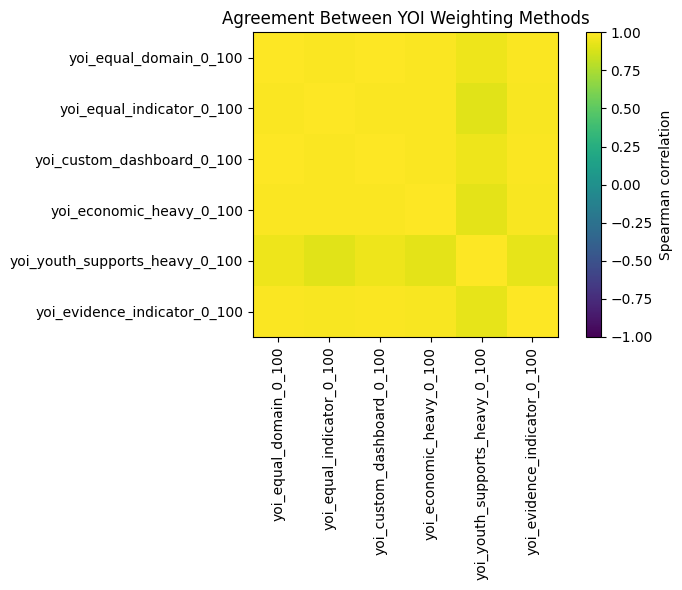

In [48]:
method_score_cols = [
    "yoi_equal_domain_0_100",
    "yoi_equal_indicator_0_100",
    "yoi_custom_dashboard_0_100",
    "yoi_economic_heavy_0_100",
    "yoi_youth_supports_heavy_0_100",
    "yoi_evidence_indicator_0_100",
]

method_score_cols = [c for c in method_score_cols if c in sensitivity.columns]

method_corr = sensitivity[method_score_cols].corr(method="spearman")

display(method_corr)

plt.figure(figsize=(8, 6))
plt.imshow(method_corr, vmin=-1, vmax=1)
plt.xticks(range(len(method_score_cols)), method_score_cols, rotation=90)
plt.yticks(range(len(method_score_cols)), method_score_cols)
plt.colorbar(label="Spearman correlation")
plt.title("Agreement Between YOI Weighting Methods")
plt.tight_layout()
plt.show()

### Validation by sensitivity group cell
- Checks whether sensitivity groups align with COI.
- Shows that low, middle, and high groups follow the expected COI pattern.

In [49]:
if "coi_merged" in globals() and "coi_score" in coi_merged.columns:
    validation_by_group = sensitivity.merge(
        coi_merged[["tract_geoid", "coi_score"]],
        on="tract_geoid",
        how="left"
    )

    group_summary = (
        validation_by_group
        .groupby("improved_sensitivity_flag")
        .agg(
            tract_count=("tract_geoid", "count"),
            mean_yoi=("yoi_equal_domain_0_100", "mean"),
            mean_sensitivity_std=("sensitivity_score_std", "mean"),
            mean_sensitivity_range=("sensitivity_score_range", "mean"),
            mean_coi=("coi_score", "mean"),
        )
        .sort_values("mean_yoi")
    )

    display(group_summary)
else:
    print("COI validation file not available.")

,tract_count,mean_yoi,mean_sensitivity_std,mean_sensitivity_range,mean_coi
improved_sensitivity_flag,,,,,
Consistently low opportunity,120,34.549961,1.315139,7.246613,24.400000
Stable middle / near county average,458,50.719127,1.197638,6.674151,67.842795
Mixed but not highly unstable,35,51.015427,1.327718,7.116957,66.571429
Truly method-sensitive,31,55.277136,3.465493,17.543400,72.366667
Consistently high opportunity,93,64.536546,1.321527,6.965956,93.623656


## Cell 17 — Score distribution
- Shows the overall YOI score distribution.
- Confirms that the score is centered around 50 with standard deviation around 10.

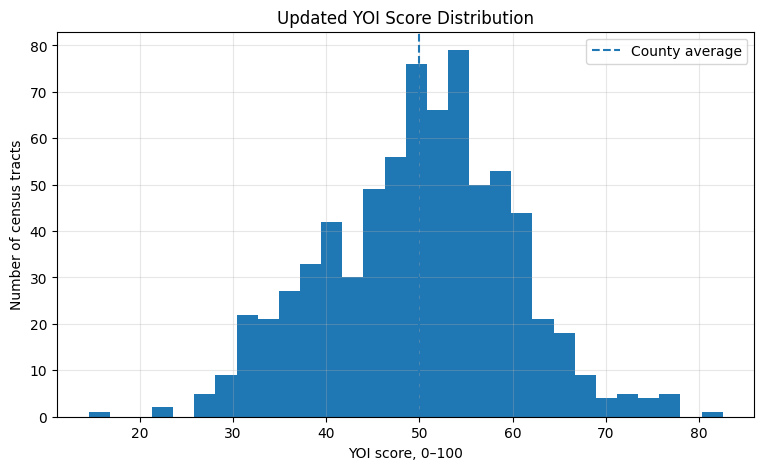

count    732.000000
mean      50.000000
std       10.006838
min       14.537491
25%       43.399140
50%       50.568043
75%       56.320235
max       82.524622
Name: yoi_z_0_100, dtype: float64

In [51]:
plt.figure(figsize=(9, 5))
plt.hist(yoi["yoi_z_0_100"].dropna(), bins=30)
plt.axvline(50, linestyle="--", label="County average")
plt.title("Updated YOI Score Distribution")
plt.xlabel("YOI score, 0–100")
plt.ylabel("Number of census tracts")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

display(yoi["yoi_z_0_100"].describe())

## Cell 18 — Opportunity level counts
- Shows how many tracts fall into each opportunity level.
- Confirms categories are not artificially equal.

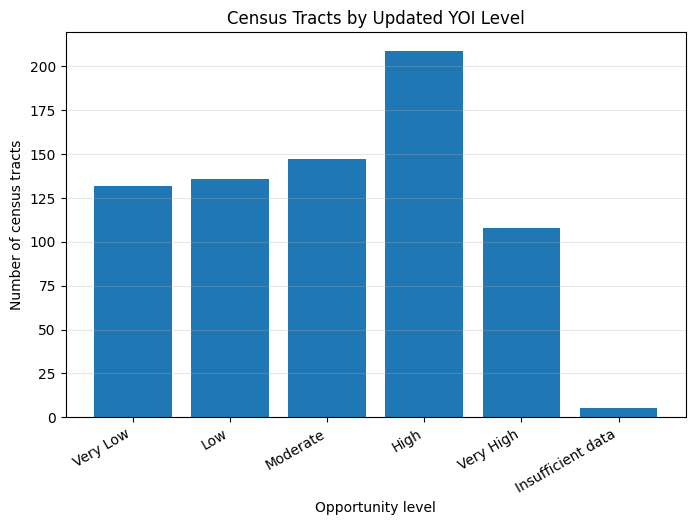

,tract_count,count
0,Very Low,132
1,Low,136
2,Moderate,147
3,High,209
4,Very High,108
5,Insufficient data,5


In [52]:
level_order = ["Very Low", "Low", "Moderate", "High", "Very High", "Insufficient data"]

level_counts = (
    yoi["yoi_z_level"]
    .value_counts()
    .reindex(level_order)
    .dropna()
)

plt.figure(figsize=(8, 5))
plt.bar(level_counts.index, level_counts.values)
plt.title("Census Tracts by Updated YOI Level")
plt.xlabel("Opportunity level")
plt.ylabel("Number of census tracts")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.show()

display(level_counts.reset_index().rename(columns={"index": "level", "yoi_z_level": "tract_count"}))

## Cell 19 — Domain spread diagnostic
- Shows how much each domain varies across tracts.
- Helps identify which domains create more variation.

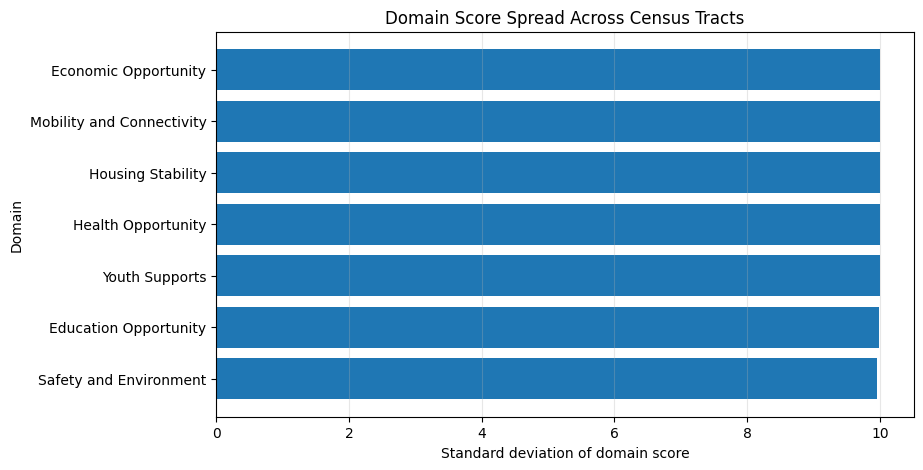

,domain,mean,std,min,median,max,below_40_count,above_60_count
4,Safety and Environment,50.009850,9.955541,0.000000,51.523979,66.323496,101,100
1,Education Opportunity,50.004336,9.984398,0.000000,50.882116,80.040374,110,112
6,Youth Supports,50.000000,10.006791,39.896533,47.101039,97.510562,52,90
2,Health Opportunity,50.000000,10.006810,21.157002,51.319146,72.105473,137,129
3,Housing Stability,50.000000,10.006838,21.734394,50.258908,74.719851,121,116
5,Mobility and Connectivity,50.000000,10.006838,10.156363,51.215972,71.578014,105,100
0,Economic Opportunity,50.000000,10.006838,12.251336,51.356159,71.140610,118,103


In [53]:
domain_spread_rows = []

for d in DOMAINS:
    col = f"{d}_score_0_100"

    if col not in yoi.columns:
        continue

    s = safe_num(yoi[col])

    domain_spread_rows.append({
        "domain": DOMAIN_LABELS[d],
        "mean": s.mean(skipna=True),
        "std": s.std(skipna=True),
        "min": s.min(skipna=True),
        "median": s.median(skipna=True),
        "max": s.max(skipna=True),
        "below_40_count": int((s < 40).sum()),
        "above_60_count": int((s >= 60).sum()),
    })

domain_spread = pd.DataFrame(domain_spread_rows).sort_values("std", ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(domain_spread["domain"], domain_spread["std"])
plt.title("Domain Score Spread Across Census Tracts")
plt.xlabel("Standard deviation of domain score")
plt.ylabel("Domain")
plt.grid(axis="x", alpha=0.3)
plt.show()

display(domain_spread)

## Cell 20 — Old vs updated YOI scatterplot
- Visual comparison between old and new scores.
- Useful for showing that the new method changes the scoring logic without completely disconnecting from the prior index.

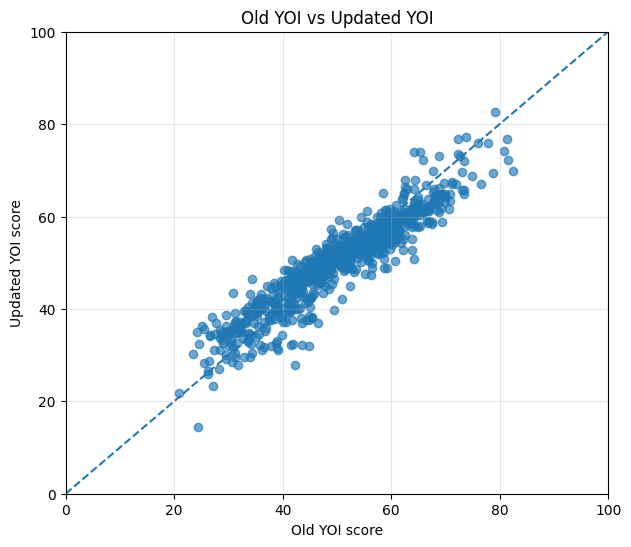

In [54]:
if old_score_col:
    plt.figure(figsize=(7, 6))
    plt.scatter(compare_old_new["old_yoi_0_100"], compare_old_new["yoi_z_0_100"], alpha=0.65)
    plt.plot([0, 100], [0, 100], linestyle="--")
    plt.title("Old YOI vs Updated YOI")
    plt.xlabel("Old YOI score")
    plt.ylabel("Updated YOI score")
    plt.xlim(0, 100)
    plt.ylim(0, 100)
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("Old score column not found.")

## Cell 22 — Sensitivity distribution

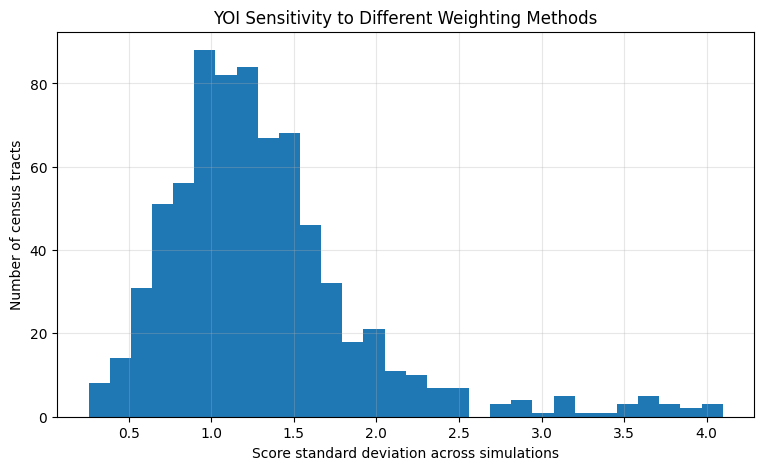

,tract_geoid,yoi_equal_domain_0_100,sensitivity_score_mean,sensitivity_score_std,sensitivity_score_range,weight_sensitivity_label,consistency_flag
618,06073009505,72.252976,71.769376,4.096825,20.216470,Moderate stability,Consistently high opportunity
270,06073018301,38.263115,38.284799,4.029744,19.761003,Moderate stability,Mixed / method-sensitive
114,06073006000,64.991510,64.561051,4.026590,18.315538,Moderate stability,Consistently high opportunity
531,06073004200,73.159225,72.642195,3.964146,18.327990,Moderate stability,Consistently high opportunity
214,06073009504,74.029757,73.496664,3.914661,18.024125,Moderate stability,Consistently high opportunity
419,06073008202,37.528210,37.519667,3.829217,22.676865,Moderate stability,Mixed / method-sensitive
273,06073007602,36.915722,36.996929,3.794412,17.796554,Moderate stability,Mixed / method-sensitive
299,06073008346,76.825754,76.296295,3.775742,17.047213,Moderate stability,Consistently high opportunity
153,06073010015,59.790127,59.461845,3.708814,17.520127,Moderate stability,Mixed / method-sensitive
126,06073008511,65.095473,64.696809,3.690901,17.083268,Moderate stability,Consistently high opportunity


In [55]:
plt.figure(figsize=(9, 5))
plt.hist(sensitivity["sensitivity_score_std"].dropna(), bins=30)
plt.title("YOI Sensitivity to Different Weighting Methods")
plt.xlabel("Score standard deviation across simulations")
plt.ylabel("Number of census tracts")
plt.grid(True, alpha=0.3)
plt.show()

display(
    sensitivity[
        [
            "tract_geoid",
            "yoi_equal_domain_0_100",
            "sensitivity_score_mean",
            "sensitivity_score_std",
            "sensitivity_score_range",
            "weight_sensitivity_label",
            "consistency_flag",
        ]
    ]
    .sort_values("sensitivity_score_std", ascending=False)
    .head(25)
)

The sensitivity distribution shows that most tract scores are stable under alternative weighting assumptions. Most tracts have low sensitivity, with score standard deviations clustered around 1–2 points. A small number of tracts have higher sensitivity, reaching about 4 points, and these should be flagged for closer domain-level review.

## Cell 23 — Static county map

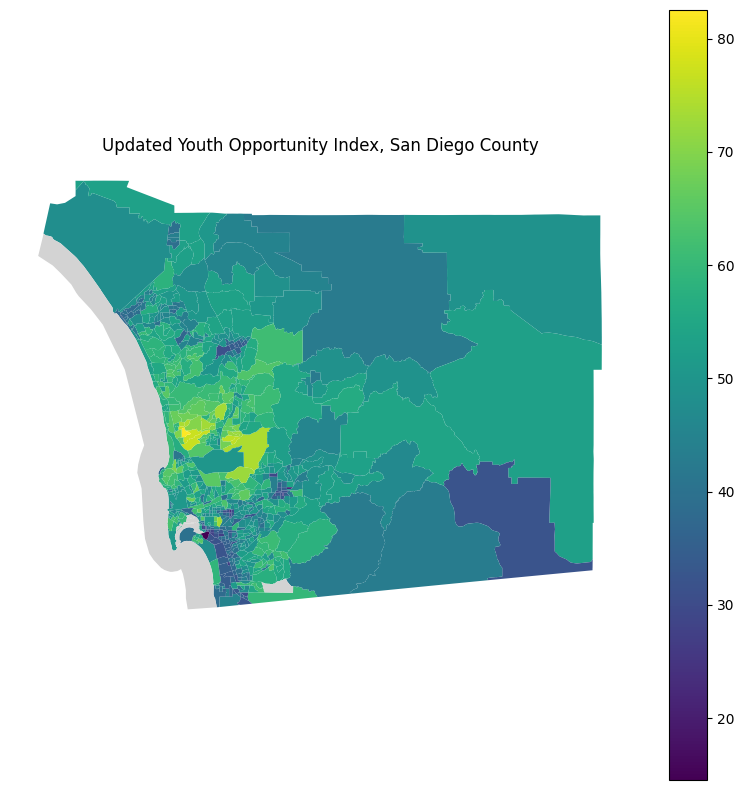

In [56]:
try:
    import geopandas as gpd

    tract_geojson = BOUNDARY_DIR / "sd_tracts.geojson"

    if not tract_geojson.exists():
        raise FileNotFoundError(f"Missing {tract_geojson}")

    tracts = gpd.read_file(tract_geojson)
    tracts["tract_geoid"] = (
        tracts["tract_geoid"]
        .astype(str)
        .str.replace(r"\D", "", regex=True)
        .str.zfill(11)
        .str[-11:]
    )

    gdf = tracts.merge(yoi, on="tract_geoid", how="left")

    fig, ax = plt.subplots(figsize=(10, 10))

    gdf.plot(
        column="yoi_z_0_100",
        ax=ax,
        legend=True,
        missing_kwds={"color": "lightgrey", "label": "Missing"},
    )

    ax.set_title("Updated Youth Opportunity Index, San Diego County")
    ax.set_axis_off()

    plt.show()

except Exception as e:
    print("Could not create static YOI map:", e)

## Cell 24 — Static weight sensitivity map

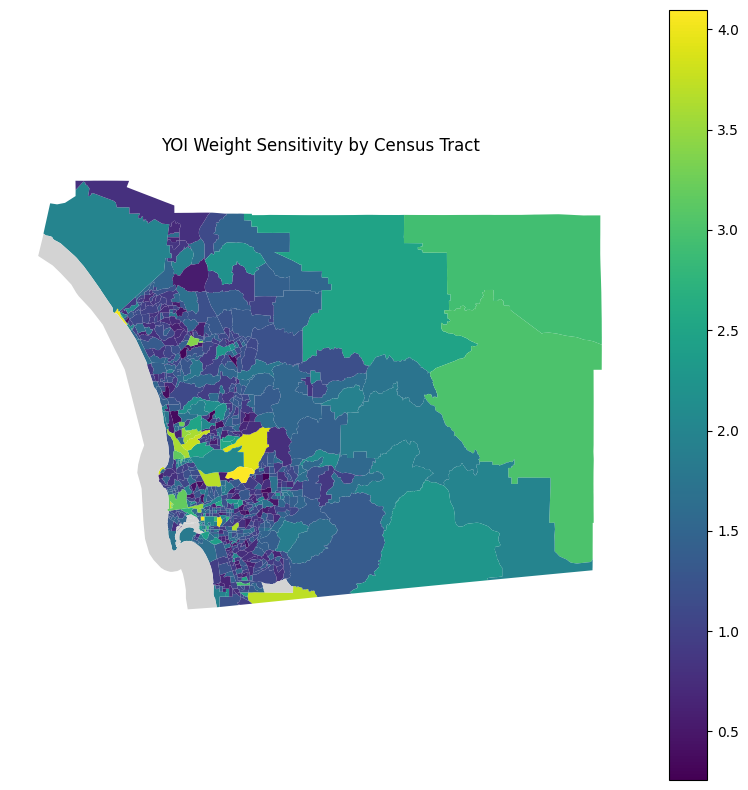

In [57]:
try:
    gdf_sens = tracts.merge(sensitivity, on="tract_geoid", how="left")

    fig, ax = plt.subplots(figsize=(10, 10))

    gdf_sens.plot(
        column="sensitivity_score_std",
        ax=ax,
        legend=True,
        missing_kwds={"color": "lightgrey", "label": "Missing"},
    )

    ax.set_title("YOI Weight Sensitivity by Census Tract")
    ax.set_axis_off()

    plt.show()

except Exception as e:
    print("Could not create static sensitivity map:", e)

## Cell 25 — Interactive YOI map

In [58]:
try:
    import folium
    import branca.colormap as cm

    map_gdf = gdf.to_crs(epsg=4326).copy()

    score_col = "yoi_z_0_100"

    colormap = cm.LinearColormap(
        colors=["#B6442C", "#E59A22", "#EEC574", "#7CC6BB", "#2B989E", "#246E7E", "#27373D"],
        vmin=0,
        vmax=100,
        caption="Updated YOI score, 0–100",
    )

    center = [
        map_gdf.geometry.centroid.y.mean(),
        map_gdf.geometry.centroid.x.mean(),
    ]

    m = folium.Map(location=center, zoom_start=10, tiles="cartodbpositron")

    def style_function(feature):
        score = feature["properties"].get(score_col)

        if score is None or pd.isna(score):
            return {
                "fillColor": "#dddddd",
                "color": "#555555",
                "weight": 0.5,
                "fillOpacity": 0.5,
            }

        return {
            "fillColor": colormap(score),
            "color": "#333333",
            "weight": 0.4,
            "fillOpacity": 0.8,
        }

    tooltip_fields = [
        "tract_geoid",
        "yoi_z_0_100",
        "yoi_z_level",
        "economic_score_0_100",
        "education_score_0_100",
        "health_score_0_100",
        "housing_score_0_100",
        "safety_env_score_0_100",
        "mobility_connectivity_score_0_100",
        "youth_supports_score_0_100",
    ]

    tooltip_fields = [c for c in tooltip_fields if c in map_gdf.columns]

    tooltip_aliases = [
        "Tract GEOID:",
        "YOI score:",
        "Opportunity level:",
        "Economic:",
        "Education:",
        "Health:",
        "Housing:",
        "Safety / Environment:",
        "Mobility / Connectivity:",
        "Youth Supports:",
    ][:len(tooltip_fields)]

    folium.GeoJson(
        map_gdf,
        name="Updated YOI",
        style_function=style_function,
        tooltip=folium.GeoJsonTooltip(
            fields=tooltip_fields,
            aliases=tooltip_aliases,
            localize=True,
            sticky=True,
        ),
    ).add_to(m)

    colormap.add_to(m)
    folium.LayerControl().add_to(m)

    out_map = YOI_DIR / "updated_yoi_county_map_corrected.html"
    m.save(out_map)

    print("Saved interactive map to:", out_map)
    display(m)

except Exception as e:
    print("Could not create interactive YOI map:", e)

Could not create interactive YOI map: No module named 'folium'


## Cell 26 — Interactive sensitivity map

In [59]:
try:
    import folium
    import branca.colormap as cm

    map_gdf = gdf_sens.to_crs(epsg=4326).copy()

    score_col = "sensitivity_score_std"

    max_sens = float(map_gdf[score_col].quantile(0.99))

    if not np.isfinite(max_sens) or max_sens <= 0:
        max_sens = float(map_gdf[score_col].max(skipna=True))

    colormap = cm.LinearColormap(
        colors=["#EEC574", "#E59A22", "#B6442C"],
        vmin=0,
        vmax=max_sens,
        caption="Weight sensitivity, standard deviation",
    )

    center = [
        map_gdf.geometry.centroid.y.mean(),
        map_gdf.geometry.centroid.x.mean(),
    ]

    m2 = folium.Map(location=center, zoom_start=10, tiles="cartodbpositron")

    def style_function_sensitivity(feature):
        score = feature["properties"].get(score_col)

        if score is None or pd.isna(score):
            return {
                "fillColor": "#dddddd",
                "color": "#555555",
                "weight": 0.5,
                "fillOpacity": 0.5,
            }

        return {
            "fillColor": colormap(score),
            "color": "#333333",
            "weight": 0.4,
            "fillOpacity": 0.8,
        }

    tooltip_fields = [
        "tract_geoid",
        "yoi_equal_domain_0_100",
        "sensitivity_score_mean",
        "sensitivity_score_std",
        "sensitivity_score_range",
        "weight_sensitivity_label",
        "consistency_flag",
    ]

    tooltip_fields = [c for c in tooltip_fields if c in map_gdf.columns]

    tooltip_aliases = [
        "Tract GEOID:",
        "Equal-domain YOI:",
        "Average simulated score:",
        "Sensitivity std:",
        "Sensitivity range:",
        "Sensitivity label:",
        "Consistency flag:",
    ][:len(tooltip_fields)]

    folium.GeoJson(
        map_gdf,
        name="YOI sensitivity",
        style_function=style_function_sensitivity,
        tooltip=folium.GeoJsonTooltip(
            fields=tooltip_fields,
            aliases=tooltip_aliases,
            localize=True,
            sticky=True,
        ),
    ).add_to(m2)

    colormap.add_to(m2)
    folium.LayerControl().add_to(m2)

    out_map = YOI_DIR / "yoi_weight_sensitivity_county_map_corrected.html"
    m2.save(out_map)

    print("Saved interactive sensitivity map to:", out_map)
    display(m2)

except Exception as e:
    print("Could not create interactive sensitivity map:", e)

Could not create interactive sensitivity map: No module named 'folium'


## Cell 27 — Save outputs

In [60]:
front_cols = [
    "tract_geoid",
    "yoi_0_100",
    "yoi_custom_0_100",
    "yoi_raw_0_1",
    "yoi_custom_0_1",
    "yoi_z_raw",
    "yoi_z_0_100",
    "yoi_z_level",
    "yoi_domain_coverage_z",
]

if "total_population" in yoi.columns:
    front_cols.insert(1, "total_population")

domain_cols = []

for d in DOMAINS:
    domain_cols.extend([
        f"{d}_score",
        f"{d}_score_z",
        f"{d}_score_0_100",
        f"{d}_coverage_z",
    ])

raw_indicator_cols = [c for c in meta["indicator"].tolist() if c in yoi.columns]
z_indicator_cols = [c for c in z_meta["z_col"].tolist() if c in yoi.columns]

extra_cols = [
    "crime_rate_per_1k",
    "service_count",
    "youth_service_count",
    "mh_service_count",
    "services_per_10k",
    "youth_services_per_10k",
    "mh_services_per_10k",
    "lack_transport",
]

save_cols = []

for c in front_cols + domain_cols + raw_indicator_cols + z_indicator_cols + extra_cols:
    if c in yoi.columns and c not in save_cols:
        save_cols.append(c)

yoi_out = yoi[save_cols].copy()

yoi_out.to_csv(OUTPUT_COMPONENTS, index=False)
z_meta.to_csv(OUTPUT_META, index=False)
sensitivity.to_csv(OUTPUT_SENSITIVITY, index=False)

if len(validation_df):
    validation_df.to_csv(OUTPUT_VALIDATION, index=False)
else:
    pd.DataFrame(
        columns=[
            "source",
            "variable",
            "n",
            "pearson_corr_with_yoi",
            "spearman_corr_with_yoi",
            "note",
        ]
    ).to_csv(OUTPUT_VALIDATION, index=False)

print("Saved:", OUTPUT_COMPONENTS)
print("Saved:", OUTPUT_META)
print("Saved:", OUTPUT_SENSITIVITY)
print("Saved:", OUTPUT_VALIDATION)

Saved: /Users/laurenvo/Documents/github/youth_opportunity_index/data/processed/yoi/yoi_components_zscore_corrected.csv
Saved: /Users/laurenvo/Documents/github/youth_opportunity_index/data/processed/yoi/yoi_zscore_indicator_meta_corrected.csv
Saved: /Users/laurenvo/Documents/github/youth_opportunity_index/data/processed/yoi/yoi_sensitivity_analysis_corrected.csv
Saved: /Users/laurenvo/Documents/github/youth_opportunity_index/data/processed/yoi/yoi_validation_summary_corrected.csv


## Cell 28 — Optional dashboard replacement

In [61]:
# Optional dashboard test:
# This will replace data/processed/yoi/yoi_components.csv with the corrected z-score output.
# Keep this commented unless we intentionally want the dashboard to use the new method.

# import shutil
#
# backup_path = YOI_DIR / "yoi_components_percentile_backup.csv"
# shutil.copy2(INPUT_COMPONENTS, backup_path)
# shutil.copy2(OUTPUT_COMPONENTS, INPUT_COMPONENTS)
#
# print("Backed up original YOI file to:", backup_path)
# print("Replaced dashboard input with:", OUTPUT_COMPONENTS)

In [62]:
# Get only the truly method-sensitive tracts
method_sensitive = sensitivity[
    sensitivity["improved_sensitivity_flag"] == "Truly method-sensitive"
].copy()

# Main score columns to compare
method_score_cols = [
    "yoi_equal_domain_0_100",
    "yoi_equal_indicator_0_100",
    "yoi_custom_dashboard_0_100",
    "yoi_economic_heavy_0_100",
    "yoi_youth_supports_heavy_0_100",
    "yoi_evidence_indicator_0_100",
    "sensitivity_score_mean",
]

method_score_cols = [c for c in method_score_cols if c in method_sensitive.columns]

# Add max/min method scores
method_sensitive["min_method_score"] = method_sensitive[method_score_cols].min(axis=1)
method_sensitive["max_method_score"] = method_sensitive[method_score_cols].max(axis=1)
method_sensitive["method_score_range"] = (
    method_sensitive["max_method_score"] - method_sensitive["min_method_score"]
)

# Find which method gives the min and max score
method_sensitive["lowest_scoring_method"] = method_sensitive[method_score_cols].idxmin(axis=1)
method_sensitive["highest_scoring_method"] = method_sensitive[method_score_cols].idxmax(axis=1)

display(
    method_sensitive[
        [
            "tract_geoid",
            "yoi_equal_domain_0_100",
            "sensitivity_score_mean",
            "sensitivity_score_std",
            "sensitivity_score_range",
            "method_score_range",
            "lowest_scoring_method",
            "highest_scoring_method",
            "low_opportunity_consistency",
            "middle_opportunity_consistency",
            "high_opportunity_consistency",
            "improved_sensitivity_flag",
        ]
    ]
    .sort_values("sensitivity_score_std", ascending=False)
)

,tract_geoid,yoi_equal_domain_0_100,sensitivity_score_mean,sensitivity_score_std,sensitivity_score_range,method_score_range,lowest_scoring_method,highest_scoring_method,low_opportunity_consistency,middle_opportunity_consistency,high_opportunity_consistency,improved_sensitivity_flag
618,06073009505,72.252976,71.769376,4.096825,20.216470,20.248695,yoi_equal_indicator_0_100,yoi_youth_supports_heavy_0_100,0.000,0.000,1.000,Truly method-sensitive
270,06073018301,38.263115,38.284799,4.029744,19.761003,6.372293,yoi_equal_domain_0_100,yoi_evidence_indicator_0_100,0.500,0.500,0.000,Truly method-sensitive
114,06073006000,64.991510,64.561051,4.026590,18.315538,20.332435,yoi_equal_indicator_0_100,yoi_youth_supports_heavy_0_100,0.000,0.250,0.750,Truly method-sensitive
531,06073004200,73.159225,72.642195,3.964146,18.327990,19.779211,yoi_equal_indicator_0_100,yoi_youth_supports_heavy_0_100,0.000,0.000,1.000,Truly method-sensitive
214,06073009504,74.029757,73.496664,3.914661,18.024125,18.739653,yoi_equal_indicator_0_100,yoi_youth_supports_heavy_0_100,0.000,0.000,1.000,Truly method-sensitive
419,06073008202,37.528210,37.519667,3.829217,22.676865,7.003281,sensitivity_score_mean,yoi_economic_heavy_0_100,0.375,0.625,0.000,Truly method-sensitive
273,06073007602,36.915722,36.996929,3.794412,17.796554,6.307624,yoi_equal_domain_0_100,yoi_evidence_indicator_0_100,0.625,0.375,0.000,Truly method-sensitive
299,06073008346,76.825754,76.296295,3.775742,17.047213,18.522278,yoi_equal_indicator_0_100,yoi_youth_supports_heavy_0_100,0.000,0.000,1.000,Truly method-sensitive
153,06073010015,59.790127,59.461845,3.708814,17.520127,19.007036,yoi_equal_indicator_0_100,yoi_youth_supports_heavy_0_100,0.000,0.875,0.125,Truly method-sensitive
126,06073008511,65.095473,64.696809,3.690901,17.083268,18.756521,yoi_equal_indicator_0_100,yoi_youth_supports_heavy_0_100,0.000,0.125,0.875,Truly method-sensitive


In [63]:
domain_score_cols = [
    "economic_score_0_100",
    "education_score_0_100",
    "health_score_0_100",
    "housing_score_0_100",
    "safety_env_score_0_100",
    "mobility_connectivity_score_0_100",
    "youth_supports_score_0_100",
]

domain_score_cols = [c for c in domain_score_cols if c in yoi.columns]

method_sensitive_detail = method_sensitive.merge(
    yoi[["tract_geoid"] + domain_score_cols],
    on="tract_geoid",
    how="left"
)

# Measure how uneven the domain profile is
method_sensitive_detail["domain_min"] = method_sensitive_detail[domain_score_cols].min(axis=1)
method_sensitive_detail["domain_max"] = method_sensitive_detail[domain_score_cols].max(axis=1)
method_sensitive_detail["domain_range"] = (
    method_sensitive_detail["domain_max"] - method_sensitive_detail["domain_min"]
)

method_sensitive_detail["lowest_domain"] = method_sensitive_detail[domain_score_cols].idxmin(axis=1)
method_sensitive_detail["highest_domain"] = method_sensitive_detail[domain_score_cols].idxmax(axis=1)

display(
    method_sensitive_detail[
        [
            "tract_geoid",
            "yoi_equal_domain_0_100",
            "sensitivity_score_std",
            "sensitivity_score_range",
            "domain_range",
            "lowest_domain",
            "highest_domain",
        ]
        + domain_score_cols
    ]
    .sort_values("sensitivity_score_std", ascending=False)
)

,tract_geoid,yoi_equal_domain_0_100,sensitivity_score_std,sensitivity_score_range,domain_range,lowest_domain,highest_domain,economic_score_0_100,education_score_0_100,health_score_0_100,housing_score_0_100,safety_env_score_0_100,mobility_connectivity_score_0_100,youth_supports_score_0_100
25,06073009505,72.252976,4.096825,20.216470,45.576505,education_score_0_100,youth_supports_score_0_100,56.690017,51.934057,57.497851,55.286607,56.579398,65.812016,97.510562
8,06073018301,38.263115,4.029744,19.761003,58.923662,safety_env_score_0_100,health_score_0_100,45.004918,48.318129,58.923662,41.977111,0.000000,49.408939,51.764388
0,06073006000,64.991510,4.026590,18.315538,45.779973,housing_score_0_100,youth_supports_score_0_100,51.937738,51.626767,54.268645,48.842955,54.192130,50.545206,94.622929
23,06073004200,73.159225,3.964146,18.327990,48.255302,safety_env_score_0_100,youth_supports_score_0_100,59.778879,60.454978,59.629733,56.892015,49.255260,62.852689,97.510562
6,06073009504,74.029757,3.914661,18.024125,46.878352,mobility_connectivity_score_0_100,youth_supports_score_0_100,60.473323,65.717885,60.141737,60.885271,55.451929,50.632210,97.510562
19,06073008202,37.528210,3.829217,22.676865,50.209041,mobility_connectivity_score_0_100,economic_score_0_100,60.365404,43.062935,55.944136,41.376699,14.601892,10.156363,55.428591
9,06073007602,36.915722,3.794412,17.796554,54.907739,safety_env_score_0_100,health_score_0_100,47.071731,51.778986,54.907739,45.744450,0.000000,46.726501,44.561008
12,06073008346,76.825754,3.775742,17.047213,42.867794,safety_env_score_0_100,youth_supports_score_0_100,61.948465,58.500846,66.082137,61.829228,54.642768,63.247636,97.510562
4,06073010015,59.790127,3.708814,17.520127,45.589145,education_score_0_100,youth_supports_score_0_100,49.333573,43.527216,49.808623,53.163285,46.897657,50.829608,89.116361
2,06073008511,65.095473,3.690901,17.083268,44.674448,safety_env_score_0_100,youth_supports_score_0_100,53.867032,51.875028,52.912052,52.904124,46.424397,59.741747,91.098845


In [64]:
# Add raw indicator columns for the method-sensitive tracts
raw_indicator_cols = [c for c in meta["indicator"].tolist() if c in yoi.columns]

method_sensitive_raw = method_sensitive_detail.merge(
    yoi[["tract_geoid"] + raw_indicator_cols],
    on="tract_geoid",
    how="left"
)

display(
    method_sensitive_raw[
        [
            "tract_geoid",
            "yoi_equal_domain_0_100",
            "sensitivity_score_std",
            "sensitivity_score_range",
            "lowest_domain",
            "highest_domain",
        ]
        + domain_score_cols
        + raw_indicator_cols
    ]
    .sort_values("sensitivity_score_std", ascending=False)
)

,tract_geoid,yoi_equal_domain_0_100,sensitivity_score_std,sensitivity_score_range,lowest_domain,highest_domain,economic_score_0_100,education_score_0_100,health_score_0_100,housing_score_0_100,safety_env_score_0_100,mobility_connectivity_score_0_100,youth_supports_score_0_100,poverty_rate,median_hh_income,unemployment_rate,snap_or_assist_rate,hs_plus,ba_plus,school_enrollment,youth_disconnection_proxy,uninsured_rate,disability_rate,frequent_mental_distress,poor_physical_health,rent_burden_proxy,overcrowding_proxy,moved_past_year_proxy,homeownership_rate,single_parent_proxy,vacancy_rate,crime_rate_per_1k,env_burden,no_vehicle_rate,commute_time_proxy,internet_sub_rate_proxy,service_count,services_per_10k
25,06073009505,72.252976,4.096825,20.216470,education_score_0_100,youth_supports_score_0_100,56.690017,51.934057,57.497851,55.286607,56.579398,65.812016,97.510562,1.9,121960.0,6.3,2.8,96.5,58.6,20.398252,9.016393,1.3,14.1,13.7,10.0,63.670412,0.818797,9.529880,69.348523,30.369128,3.071084,7.317849,18.494088,0.783197,17.569243,98.291207,107.0,170.219535
8,06073018301,38.263115,4.029744,19.761003,safety_env_score_0_100,health_score_0_100,45.004918,48.318129,58.923662,41.977111,0.000000,49.408939,51.764388,9.2,74524.0,11.6,3.6,98.8,59.0,4.988399,0.000000,5.0,6.8,13.9,11.0,65.243902,1.215278,26.546682,40.277778,58.333333,61.054767,291.338583,NaN,4.861111,48.895899,98.090278,3.0,33.745782
0,06073006000,64.991510,4.026590,18.315538,housing_score_0_100,youth_supports_score_0_100,51.937738,51.626767,54.268645,48.842955,54.192130,50.545206,94.622929,14.1,102404.0,3.6,3.5,96.8,65.1,11.065405,0.000000,0.6,17.0,14.1,10.8,43.835616,0.635039,24.804607,42.734404,0.000000,6.594557,33.440774,44.206596,8.703773,25.449275,94.471423,45.0,90.652699
23,06073004200,73.159225,3.964146,18.327990,safety_env_score_0_100,youth_supports_score_0_100,59.778879,60.454978,59.629733,56.892015,49.255260,62.852689,97.510562,3.6,160127.0,6.0,1.0,97.6,65.5,25.405507,0.000000,4.2,6.8,14.9,9.9,40.659341,4.688832,10.868788,62.148338,13.997308,6.009615,15.498415,72.557561,0.895141,26.313523,98.763853,123.0,216.625572
6,06073009504,74.029757,3.914661,18.024125,mobility_connectivity_score_0_100,youth_supports_score_0_100,60.473323,65.717885,60.141737,60.885271,55.451929,50.632210,97.510562,3.2,NaN,2.9,4.4,98.7,77.2,29.604950,0.000000,0.7,14.5,12.6,9.1,50.622407,0.339559,8.206972,78.607810,9.553350,10.007639,7.778469,29.956441,0.000000,51.480781,96.095076,94.0,146.235221
19,06073008202,37.528210,3.829217,22.676865,mobility_connectivity_score_0_100,economic_score_0_100,60.365404,43.062935,55.944136,41.376699,14.601892,10.156363,55.428591,3.9,111836.0,1.3,0.0,94.4,60.8,2.521008,NaN,0.0,16.5,9.3,12.7,71.608040,2.276176,21.862012,36.267071,NaN,38.295880,34.081463,NaN,35.660091,51.250000,84.673748,5.0,41.562760
9,06073007602,36.915722,3.794412,17.796554,safety_env_score_0_100,health_score_0_100,47.071731,51.778986,54.907739,45.744450,0.000000,46.726501,44.561008,17.1,135798.0,8.3,9.2,98.2,63.8,10.766629,0.000000,2.8,13.1,16.3,9.3,32.576769,0.000000,32.299887,25.570342,NaN,37.971698,110.484780,NaN,11.596958,45.198675,100.000000,2.0,11.273957
12,06073008346,76.825754,3.775742,17.047213,safety_env_score_0_100,youth_supports_score_0_100,61.948465,58.500846,66.082137,61.829228,54.642768,63.247636,97.510562,3.2,183698.0,4.4,4.3,96.7,73.1,20.560976,0.609756,2.0,6.9,12.4,8.4,32.994924,1.184539,13.098058,74.937656,7.769424,5.647059,28.790341,37.299315,1.683292,21.424367,98.129676,88.0,204.318551
4,06073010015,59.790127,3.708814,17.520127,education_score_0_100,youth_supports_score_0_100,49.333573,43.527216,49.808623,53.163285,46.897657,50.829608,89.116361,5.8,131029.0,10.1,11.3,79.0,31.9,24.042725,3.883495,7.8,10.3,16.7,11.9,55.000000,9.103641,11.133083,78.781513,12.351946,8.695652,0.000000,92.769135,3.641457,47.006129,97.689076,39.0,75.596046
2,06073008511,65.095473,3.690901,17.083268,safety_env_score_0_100,youth_supports_score_0_100,53.867032,51.875028,52.912052,52.904124,46.424397,59.7

In [66]:
# Find tracts with missing final YOI scores
null_tracts = yoi[yoi["yoi_z_0_100"].isna()].copy()

print("Number of tracts with null YOI:", len(null_tracts))

cols_to_show = [
    "tract_geoid",
    "yoi_z_0_100",
    "yoi_z_level",
    "yoi_domain_coverage_z",
]

if "total_population" in yoi.columns:
    cols_to_show.insert(1, "total_population")

domain_score_cols = [f"{d}_score_z" for d in DOMAINS]
domain_coverage_cols = [f"{d}_coverage_z" for d in DOMAINS]

display(null_tracts[cols_to_show + domain_score_cols + domain_coverage_cols])

Number of tracts with null YOI: 5


,tract_geoid,total_population,yoi_z_0_100,yoi_z_level,yoi_domain_coverage_z,economic_score_z,education_score_z,health_score_z,housing_score_z,safety_env_score_z,mobility_connectivity_score_z,youth_supports_score_z,economic_coverage_z,education_coverage_z,health_coverage_z,housing_coverage_z,safety_env_coverage_z,mobility_connectivity_coverage_z,youth_supports_coverage_z
116,06073006300,2038,NaN,Insufficient data,0.571429,NaN,-0.533796,-0.107542,NaN,-0.061986,NaN,-0.974858,0.25,1.0,0.5,0.25,0.50,0.333333,1.0
131,06073009902,0,NaN,Insufficient data,0.142857,NaN,NaN,NaN,NaN,NaN,NaN,-0.302675,0.00,0.0,0.0,0.00,0.25,0.000000,0.5
380,06073010016,3170,NaN,Insufficient data,0.428571,NaN,-3.190085,-0.411841,NaN,NaN,NaN,-0.819182,0.00,1.0,0.5,0.25,0.25,0.000000,1.0
436,06073990100,0,NaN,Insufficient data,0.142857,NaN,NaN,NaN,NaN,NaN,NaN,-0.167408,0.00,0.0,0.0,0.00,0.00,0.000000,0.5
519,06073006200,28,NaN,Insufficient data,0.571429,NaN,-1.058782,0.129983,NaN,-3.400920,NaN,2.104267,0.25,0.5,0.5,0.25,0.50,0.333333,1.0


In [67]:
def missing_domains_for_row(row):
    missing = []
    for d in DOMAINS:
        if pd.isna(row.get(f"{d}_score_z")):
            missing.append(d)
    return missing

null_tracts["missing_domains"] = null_tracts.apply(missing_domains_for_row, axis=1)

display(
    null_tracts[
        [
            "tract_geoid",
            "yoi_domain_coverage_z",
            "missing_domains",
        ]
    ]
)

,tract_geoid,yoi_domain_coverage_z,missing_domains
116,06073006300,0.571429,"[economic, housing, mobility_connectivity]"
131,06073009902,0.142857,"[economic, education, health, housing, safety_..."
380,06073010016,0.428571,"[economic, housing, safety_env, mobility_conne..."
436,06073990100,0.142857,"[economic, education, health, housing, safety_..."
519,06073006200,0.571429,"[economic, housing, mobility_connectivity]"


In [68]:
# Check raw indicator coverage for the null tracts
raw_indicator_cols = [c for c in meta["indicator"].tolist() if c in yoi.columns]

null_indicator_check = []

for _, row in null_tracts.iterrows():
    tract = row["tract_geoid"]
    
    for _, m in meta.iterrows():
        ind = m["indicator"]
        domain = m["domain"]
        
        if ind not in yoi.columns:
            continue
        
        value = row[ind]
        
        null_indicator_check.append({
            "tract_geoid": tract,
            "domain": domain,
            "indicator": ind,
            "value": value,
            "is_missing": pd.isna(value),
        })

null_indicator_check = pd.DataFrame(null_indicator_check)

display(
    null_indicator_check
    .groupby(["tract_geoid", "domain"])
    .agg(
        indicators=("indicator", "count"),
        missing_indicators=("is_missing", "sum"),
    )
    .reset_index()
)

,tract_geoid,domain,indicators,missing_indicators
0,06073006200,economic,4,3
1,06073006200,education,4,2
2,06073006200,health,4,2
3,06073006200,housing,4,3
4,06073006200,mobility_connectivity,3,2
5,06073006200,safety_env,4,2
6,06073006200,youth_supports,2,0
7,06073006300,economic,4,3
8,06073006300,education,4,0
9,06073006300,health,4,2
